# 5강: Multi-Agent 시스템 (LangGraph)

이 노트북은 LangGraph를 이용한 Multi-Agent 패턴을 단계별로 학습합니다.

| 섹션 | 핵심 개념 |
|------|-----------|
| Dynamic Interrupt | 실행 중 그래프를 멈추고 사용자에게 질의 |
| Interrupts in Tools | 도구 호출 내부에서 Interrupt 사용 |
| Validating Human Input | 사용자 입력값 검증 루프 |
| Command with Goto | 노드에서 직접 다음 경로를 지정 |
| Subgraph | 그래프 안에 또 다른 그래프 (모듈화) |
| Multi-Agent (Supervisor) | 감독관이 팀원을 지시하는 중앙 집중형 |
| Multi-Agent (Handoff) | 에이전트끼리 직접 업무를 넘기는 네트워크형 |


## ⚙️ 환경 설정

In [1]:
# 필요한 라이브러리를 설치합니다.
# - langgraph  : 상태 기반 에이전트 그래프 프레임워크
# - langchain  : LLM 통합 레이어
# - langchain-openai : OpenAI 모델 연동
!pip install -qU langgraph langchain langchain-google-genai langchain-openai


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os

# OpenAI API 키를 환경 변수로 설정합니다.
# 실제 강의 환경에서는 이 값을 입력하세요.
os.environ["OPENAI_API_KEY"] = "sk-proj-여기에_본인_API_키_입력"

---
# 1. Dynamic Interrupt

## 개념 설명

`interrupt()`는 그래프 실행 **도중** 멈추고, 외부(사용자/시스템)에게 정보를 요청한 뒤  
다시 실행을 이어가는 기능입니다.

```
실행 시작 → agent_node 진입 → interrupt() 호출 → 실행 일시 정지 ⏸
  ↑                                                              ↓
  └─────────── Command(resume=사용자_답변) ────────────────────────┘
```

### 언제 쓰나요?
- 조건에 따라 **동적으로** 질문이 필요할 때
- 실행 흐름의 어느 지점에서든 사람의 개입이 필요할 때

### 참고 문서
- [LangGraph Interrupt 공식 문서](https://langchain-ai.github.io/langgraph/concepts/human_in_the_loop/)


## 1-1. Basic
### Model 정의

In [3]:
from langchain.chat_models import init_chat_model

# init_chat_model: 모델 이름만 넘기면 적절한 Provider를 자동으로 연결해 줍니다.
# 'gpt-5-nano'는 OpenAI의 경량 모델입니다.
model = init_chat_model("gpt-5-nano")

### State 정의

In [20]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    # messages: 대화 내역을 누적 저장합니다.
    # add_messages 리듀서는 새 메시지를 덮어쓰지 않고 '추가(append)'합니다.
    messages: Annotated[list[AnyMessage], add_messages]

    # context: 노드 간 공유해야 하는 임시 데이터를 저장하는 딕셔너리입니다.
    # 예) 사용자가 선택한 음식 종류, 위치 정보 등
    context: dict  # 수집된 정보를 저장할 공간

### Node 정의

In [21]:
from langchain.messages import SystemMessage
from langgraph.types import interrupt

def agent_node(state: ChatState):
    """
    맛집 추천 에이전트 노드.

    동작 흐름:
    1. context에서 음식 카테고리 정보를 확인합니다.
    2. 정보가 없으면 interrupt()로 실행을 멈추고 사용자에게 질문합니다.
    3. 정보가 확보되면 LLM을 호출해 실제 맛집을 추천합니다.
    """

    # ── Step 1: Context에서 이전에 수집한 정보 꺼내기 ──
    # state.get()은 키가 없어도 에러 없이 None을 반환합니다.
    ctx = state.get("context", {})
    food_category = ctx.get("food_category")

    # ── Step 2: [Dynamic Interrupt] 정보가 없으면 실행 중단 ──
    if not food_category:
        print("⏸️ [System] 음식 종류 정보 부재. 사용자에게 질의(Interrupt) 시도...")

        # interrupt()를 호출하면:
        #   - 그래프 실행이 여기서 일시 정지됩니다.
        #   - 인자로 전달한 문자열이 '질문 내용'으로 저장됩니다.
        #   - 외부에서 Command(resume=답변)을 보내면 이 줄에서 다시 시작됩니다.
        #   - resume으로 넘어온 값이 food_category 변수에 저장됩니다.
    food_category = interrupt('당신은 지금 어떤 종류의 음식을 먹고 싶으신가요? (예: 한식, 중식, 일식)')

    # ── Step 3: [LLM Generation] 확보된 카테고리로 맛집 추천 ──
    system_prompt = SystemMessage(content=f"""
    당신은 서울의 맛집 전문가입니다.
    사용자가 원하는 카테고리인 '{food_category}'에 맞춰서
    실제로 유명한 맛집 1곳을 추천하고, 추천 이유를 2문장으로 설명해주세요.
    """)

    # 시스템 프롬프트를 앞에 붙이고 LLM 호출
    messages = [system_prompt] + state["messages"]
    response = model.invoke(messages)

    # ── Step 4: 결과 반환 ──
    # 다음 실행 시에도 food_category를 기억하도록 context에 저장합니다.
    return {
        "messages": [response],
        "context": {"food_category": food_category}
    }

### 그래프 생성

In [22]:
from langgraph.graph import StateGraph, START, END

# StateGraph에 우리가 정의한 ChatState를 연결합니다.
workflow = StateGraph(ChatState)

# 노드 등록: 이름(문자열) -> 실행할 함수
workflow.add_node("chatbot", agent_node)

# 엣지 등록: START -> chatbot -> END (단순 선형 흐름)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

In [23]:
# InMemorySaver: 대화 상태(체크포인트)를 메모리에 저장합니다.
# Interrupt가 발생했을 때 '어디서 멈췄는지'를 기억하기 위해 반드시 필요합니다.
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

In [24]:
# compile(): 워크플로우를 실행 가능한 앱(app)으로 변환합니다.
# checkpointer를 연결해야 Interrupt 기능이 활성화됩니다.
app = workflow.compile(checkpointer=memory)

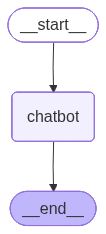

In [25]:
# 그래프 구조 시각화 (Jupyter 환경에서 실행 시 이미지가 렌더링됩니다)
app

In [26]:
# thread_id: 대화 세션을 구분하는 고유 ID입니다.
# 같은 thread_id를 사용하면 이전 대화 내역과 상태가 유지됩니다.
config_1 = {"configurable": {"thread_id": "1"}}

In [27]:
from langchain.messages import HumanMessage

# 첫 번째 메시지: 음식 종류(context)를 비워두고 호출합니다.
# agent_node 내부에서 food_category가 없다는 것을 감지하고 interrupt()를 실행합니다.
input_msg1 = {
    "messages": [HumanMessage(content="강남역 근처 맛집 추천해줘.")],
    "context" : {}  # 비어있음 -> Interrupt 발생 예상
}

response1 = app.invoke(input_msg1, config=config_1)

⏸️ [System] 음식 종류 정보 부재. 사용자에게 질의(Interrupt) 시도...


In [28]:
response1

{'messages': [HumanMessage(content='강남역 근처 맛집 추천해줘.', additional_kwargs={}, response_metadata={}, id='3fb733b1-1659-4284-8274-124a70bcc328')],
 'context': {},
 '__interrupt__': [Interrupt(value='당신은 지금 어떤 종류의 음식을 먹고 싶으신가요? (예: 한식, 중식, 일식)', id='be26eeda1452c4484f585c2694982061')]}

In [29]:
# 현재 그래프 상태 확인: 어디서 멈춰있는지 조회합니다.
# snapshot.next: 다음에 실행될 노드 이름 (Interrupt 대기 중이면 채워짐)
# snapshot.tasks[0].interrupts[0].value: interrupt()에 전달된 질문 내용
snapshot = app.get_state(config_1)
if snapshot.next:
    print(f"\n⚠️ 그래프 상태: {snapshot.next} (Interrupt 대기 중)")
    print(f"❓ 질문 내용: {snapshot.tasks[0].interrupts[0].value}")


⚠️ 그래프 상태: ('chatbot',) (Interrupt 대기 중)
❓ 질문 내용: 당신은 지금 어떤 종류의 음식을 먹고 싶으신가요? (예: 한식, 중식, 일식)


In [30]:
# ─── 사용자 응답 전달 ───
# Command(resume=값): 멈춰있던 interrupt() 지점에 값을 던져줍니다.
# 이 값이 interrupt()의 반환값(food_category)으로 사용됩니다.
from langgraph.types import Command

# 사용자가 UI에서 '일식'이라고 입력했다고 가정합니다.
resume_command = Command(resume='일식')

#### [Command 공식 참고](https://reference.langchain.com/python/langgraph/types/?h=command#langgraph.types.Command)

`Command`는 그래프 실행을 제어하는 객체입니다.
- `Command(resume=값)`: 멈춘 지점에 값을 전달하고 재개
- `Command(goto=노드명)`: 지정한 노드로 즉시 점프
- `Command(update=상태변경)`: 상태를 업데이트하면서 이동

In [31]:
# 이전 config_1을 그대로 사용해야 같은 스레드(대화 세션)에서 이어서 실행됩니다.
result_2 = app.invoke(resume_command, config=config_1)

⏸️ [System] 음식 종류 정보 부재. 사용자에게 질의(Interrupt) 시도...


In [32]:
result_2

{'messages': [HumanMessage(content='강남역 근처 맛집 추천해줘.', additional_kwargs={}, response_metadata={}, id='3fb733b1-1659-4284-8274-124a70bcc328'),
  AIMessage(content='추천 맛집: 카츠야 강남역점\n\n합리적인 가격에 바삭하고 두툼한 돈까스를 즐길 수 있어 인기가 많습니다. 강남역에서 도보로 5분 내외의 편리한 접근성과 캐주얼한 분위기로 가볍게 식사하기 좋습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 3344, 'prompt_tokens': 76, 'total_tokens': 3420, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 3264, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5Tb68w3IgWCEQvvN29uT6pdmQ1e', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ce95c-1cd0-7080-890b-ae22c9961fcb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 3344, 'total_to

In [34]:
from langchain_core.messages import HumanMessage, AIMessage


def display_state(state: dict) -> None:
    """LangGraph State를 보기 좋게 출력합니다."""
    
    RESET  = "\033[0m"
    BOLD   = "\033[1m"
    CYAN   = "\033[96m"
    GREEN  = "\033[92m"
    YELLOW = "\033[93m"
    GRAY   = "\033[90m"
    BLUE   = "\033[94m"
    WHITE  = "\033[97m"

    def divider(char="─", width=60):
        print(f"{GRAY}{char * width}{RESET}")

    # ── Header ──────────────────────────────────────────────
    print(f"\n{BOLD}{CYAN}{'━' * 60}{RESET}")
    print(f"{BOLD}{CYAN}  📋  LangGraph State Viewer{RESET}")
    print(f"{BOLD}{CYAN}{'━' * 60}{RESET}\n")

    # ── Messages ────────────────────────────────────────────
    messages = state.get("messages", [])
    print(f"{BOLD}{WHITE}💬 Messages  ({len(messages)}){RESET}")
    divider()

    for msg in messages:
        if isinstance(msg, HumanMessage):
            role_tag = f"{BOLD}{BLUE}[Human]{RESET}"
        elif isinstance(msg, AIMessage):
            role_tag = f"{BOLD}{GREEN}[AI]   {RESET}"
        else:
            role_tag = f"{BOLD}{GRAY}[?]    {RESET}"

        print(f"  {role_tag} {msg.content}")

        # AI 메시지 메타데이터
        if isinstance(msg, AIMessage):
            meta = msg.response_metadata
            usage = msg.usage_metadata or {}
            model  = meta.get("model_name", "N/A")
            finish = meta.get("finish_reason", "N/A")
            run_id = str(msg.id)[:8] + "…" if msg.id else "N/A"

            print(f"  {GRAY}  model  : {model}{RESET}")
            print(f"  {GRAY}  finish : {finish}{RESET}")
            print(f"  {GRAY}  run_id : {run_id}{RESET}")

            if usage:
                i_tok = usage.get("input_tokens",  0)
                o_tok = usage.get("output_tokens", 0)
                r_tok = usage.get("output_token_details", {}).get("reasoning", 0)
                print(f"  {GRAY}  tokens : in={i_tok}  out={o_tok}  reasoning={r_tok}{RESET}")

        print()

    # ── Context ─────────────────────────────────────────────
    context = state.get("context", {})
    if context:
        print(f"{BOLD}{WHITE}🗂  Context{RESET}")
        divider()
        for k, v in context.items():
            print(f"  {YELLOW}{k:<20}{RESET} {v}")
        print()

    print(f"{GRAY}{'━' * 60}{RESET}\n")



display_state(result_2)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📋  LangGraph State Viewer
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

💬 Messages  (2)
────────────────────────────────────────────────────────────
  [Human] 강남역 근처 맛집 추천해줘.

  [AI]    추천 맛집: 카츠야 강남역점

합리적인 가격에 바삭하고 두툼한 돈까스를 즐길 수 있어 인기가 많습니다. 강남역에서 도보로 5분 내외의 편리한 접근성과 캐주얼한 분위기로 가볍게 식사하기 좋습니다.
    model  : gpt-5-nano-2025-08-07
    finish : stop
    run_id : lc_run--…
    tokens : in=76  out=3344  reasoning=3264

🗂  Context
────────────────────────────────────────────────────────────
  food_category        일식

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [33]:
# 최종 AI 응답 메시지만 출력합니다.
result_2['messages'][-1].content

'추천 맛집: 카츠야 강남역점\n\n합리적인 가격에 바삭하고 두툼한 돈까스를 즐길 수 있어 인기가 많습니다. 강남역에서 도보로 5분 내외의 편리한 접근성과 캐주얼한 분위기로 가볍게 식사하기 좋습니다.'

In [36]:
# ─── 같은 스레드에서 두 번째 대화 (context 유지 확인) ───
# 이미 food_category='일식'이 context에 저장되어 있으므로
# 이번에는 interrupt가 발생하지 않고 바로 추천 결과가 나옵니다.
input_msg2 = {
    "messages": [HumanMessage(content="이천 하이닉스 정문 근처 일식 맛집 추천해줘.")],
}
response2 = app.invoke(input_msg2, config=config_1)
response2

{'messages': [HumanMessage(content='강남역 근처 맛집 추천해줘.', additional_kwargs={}, response_metadata={}, id='3fb733b1-1659-4284-8274-124a70bcc328'),
  AIMessage(content='추천 맛집: 카츠야 강남역점\n\n합리적인 가격에 바삭하고 두툼한 돈까스를 즐길 수 있어 인기가 많습니다. 강남역에서 도보로 5분 내외의 편리한 접근성과 캐주얼한 분위기로 가볍게 식사하기 좋습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 3344, 'prompt_tokens': 76, 'total_tokens': 3420, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 3264, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5Tb68w3IgWCEQvvN29uT6pdmQ1e', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ce95c-1cd0-7080-890b-ae22c9961fcb-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 3344, 'total_to

---
# 2. Interrupts in Tools

## 개념 설명

LLM이 스스로 "사람에게 물어봐야겠다"고 판단하면  
`ask_human` **도구(Tool)**를 호출하고, 이 도구 내부에서 `interrupt()`를 발생시키는 패턴입니다.

```
agent_node → LLM이 ask_human 도구 선택
           → human_node 실행 → interrupt() 발생 ⏸
           → Command(resume=답변) 전달
           → human_node가 ToolMessage로 포장하여 반환
           → agent_node 재실행 → 최종 답변 생성
```

### Basic Interrupt와의 차이점

| 구분 | Basic Interrupt | Interrupts in Tools |
|------|----------------|---------------------|
| 누가 결정 | 개발자가 코드로 지정 | LLM이 스스로 판단 |
| 질문 내용 | 고정된 질문 | LLM이 동적으로 생성 |
| 유연성 | 낮음 | 높음 (Agentic) |


### Model & Tool 정의

In [179]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-5-nano")

In [180]:
from langchain.tools import tool

@tool
def ask_human(question: str) -> str:
    """
    사용자에게 추가 정보를 물어볼 때 사용하는 도구입니다.
    사용자의 답변을 받으려면 이 도구를 호출하세요.
    """
    # ⚠️ 이 함수 본체는 실제로 실행되지 않습니다.
    # 아래 human_node에서 interrupt()로 실제 동작을 대체합니다.
    # LLM에게 '이런 도구가 있다'는 것만 알려주는 역할(시그니처)입니다.
    return "Human input required"

In [181]:
# 에이전트가 사용할 수 있는 도구 목록
tools = [ask_human]

### State 정의

In [182]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    # 이번 예제는 messages만으로 상태를 관리합니다.
    # ToolMessage도 messages 리스트에 누적됩니다.
    messages: Annotated[list[AnyMessage], add_messages]

### Node 정의

In [183]:
# ── 메인 에이전트 노드 ──
def agent_node(state: ChatState):
    """
    LLM이 도구를 선택하는 노드.
    ask_human 도구를 bind해두면 LLM이 필요할 때 스스로 호출합니다.
    """
    # bind_tools: LLM에게 '이 도구들을 쓸 수 있다'고 알려줍니다.
    llm_with_tools = model.bind_tools(tools)

    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [184]:
from langchain.messages import ToolMessage

def human_node(state: ChatState):
    """
    AI가 'ask_human' 도구를 호출했을 때 실행되는 노드입니다.

    핵심 역할:
    1. AI가 요청한 질문을 꺼내어 interrupt()로 사용자에게 전달
    2. 사용자 답변을 ToolMessage(도구 실행 결과)로 포장하여 반환
       → AI가 '도구가 이런 결과를 돌려줬구나'라고 인식하게 됩니다.
    """
    # ── Step 1: AI가 요청한 도구 호출 정보(질문 내용) 가져오기 ──
    last_message = state["messages"][-1]      # AI의 마지막 메시지
    tool_call = last_message.tool_calls[0]      # 첫 번째 도구 호출 정보
    question_to_user = tool_call["args"]["question"]  # ask_human의 question 인자

    # ── Step 2: [Dynamic Interrupt] 실행 중단 후 사용자 입력 대기 ──
    user_answer = interrupt(question_to_user)

    # ── Step 3: 답변을 ToolMessage로 포장 ──
    # tool_call_id: AI가 보낸 도구 호출 ID와 반드시 일치해야 합니다.
    return {
        'messages' : [
            ToolMessage(
                content = user_answer,
                tool_call_id = tool_call['id']
            )
        ]
    }

### 그래프 생성

In [185]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(ChatState)

# 두 노드 등록
workflow.add_node("agent", agent_node)
workflow.add_node("human_node", human_node)

In [186]:
# ── 조건부 라우터 함수 ──
def should_continue(state: ChatState):
    """마지막 메시지에 도구 호출이 있으면 human_node로, 없으면 종료합니다."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:   # AI가 도구를 호출했다면
        return 'human_node'        # → human_node로 이동
    else:
        return END                 # → 그래프 종료

In [187]:
# add_conditional_edges: 조건에 따라 다른 노드로 분기합니다.
workflow.add_conditional_edges(
    "agent",           # 출발 노드
    should_continue,    # 조건 함수
    ["human_node", END] # 가능한 목적지 목록
)

In [188]:
workflow.add_edge(START, "agent")
# human_node가 사용자 답변을 받은 후 다시 agent로 돌아가서
# AI가 답변을 보고 최종 응답을 생성합니다.
workflow.add_edge("human_node", "agent")

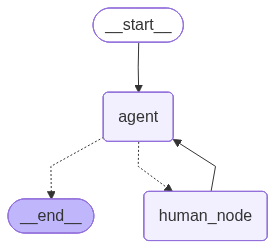

In [189]:
memory = InMemorySaver()
app = workflow.compile(checkpointer=memory)
app

In [190]:
thread_config = {"configurable": {"thread_id": "2"}}

In [191]:
from langchain.messages import SystemMessage, HumanMessage

# 시스템 프롬프트: '모르면 반드시 도구를 호출해 물어보세요'라고 지시합니다.
input_data = {
    "messages": [
        SystemMessage(content="당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요."),
        HumanMessage(content="맛집 추천 좀 해줄래?")
    ]
}

In [194]:
# 위치와 메뉴를 모르므로 LLM이 스스로 ask_human 도구를 호출 → Interrupt 발생
result_1 = app.invoke(input_data, config=thread_config)
result_1

BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_nQ2ux8L8RMVci6ice5siJm5v", 'type': 'invalid_request_error', 'param': 'messages', 'code': None}}

In [50]:
snapshot = app.get_state(thread_config)
snapshot.next  # 현재 대기 중인 노드 확인

('human_node',)

In [51]:
# 현재 그래프 상태 확인 및 질문 내용 추출
snapshot = app.get_state(thread_config)
if snapshot.next:
    # interrupt()에 전달된 질문 내용 (실제 서비스에선 이걸 프론트엔드로 보냄)
    question = snapshot.tasks[0].interrupts[0].value
    print(f"AI의 질문: {question}")

question

AI의 질문: 맛집 추천을 드리려면 정보를 조금만 더 알려주시면 좋습니다. 아래 정보를 알려주실 수 있을까요?
- 위치: 도시/동네 또는 이동 가능한 지역
- 선호하는 요리/메뉴 (예: 한식, 중식, 일식, 양식 등) 또는 피하고 싶은 종류
- 예산대(1인당 대략 얼마 정도)
- 인원 수와 예약 여부(당일 여부 포함)
- 분위기 선호(캐주얼, 데이트, 가족, 비즈니스 등) 및 특별한 식단/알레르기 여부
이 정보를 주시면 바로 맞춤 추천 드리겠습니다!


'맛집 추천을 드리려면 정보를 조금만 더 알려주시면 좋습니다. 아래 정보를 알려주실 수 있을까요?\n- 위치: 도시/동네 또는 이동 가능한 지역\n- 선호하는 요리/메뉴 (예: 한식, 중식, 일식, 양식 등) 또는 피하고 싶은 종류\n- 예산대(1인당 대략 얼마 정도)\n- 인원 수와 예약 여부(당일 여부 포함)\n- 분위기 선호(캐주얼, 데이트, 가족, 비즈니스 등) 및 특별한 식단/알레르기 여부\n이 정보를 주시면 바로 맞춤 추천 드리겠습니다!'

In [52]:
from langgraph.types import Command

# 사용자가 자연어로 답변합니다 (구조화된 답변이 아니어도 됩니다)
natural_language_answer = "음... 오늘은 비도 오고 하니까 따뜻한 우동이나 일식 같은 게 먹고 싶어."

# Command(resume=값): 멈춘 지점에 사용자 답변을 전달합니다.
resume_command = Command(resume=natural_language_answer)

In [53]:
result_2 = app.invoke(resume_command, config=thread_config)

In [54]:
result_2

{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='28cd066d-2fd4-4d58-8698-d35a91734f9a'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='645402fc-c019-48e9-a973-a32aaa79d79f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 998, 'prompt_tokens': 186, 'total_tokens': 1184, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 832, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5Z4DETIM95pwq0dvhkl6CZMIiph', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce961-484b-7e41-a9e3-6b3b9087fb01-0', tool_calls=[{'name': 'ask_human', 'args': {'questio

In [55]:
result_2['messages'][-1].content

''

---
# 3. Validating Human Input

## 개념 설명

`interrupt()`를 **while 루프** 안에서 반복 호출하면  
사용자 입력을 검증하고, 실패 시 재질문하는 루프를 구현할 수 있습니다.

```
human_validating_node 진입
  ↓
  while True:
    interrupt(질문) ─── 사용자 입력 대기 ⏸
      ↓ 재개
    입력값 검증
    ├─ 통과 → ToolMessage 반환 (루프 탈출)
    └─ 실패 → 에러 메시지와 함께 다시 interrupt() ⏸
```


### Model & Tool 정의
*(이전 섹션의 `model`, `tools`, `ask_human`을 그대로 사용합니다.)*

### State 정의
*(이전 섹션의 `ChatState`를 그대로 사용합니다.)*

### Node 정의

In [56]:
# ── [핵심] 검증 로직이 포함된 Human Node ──
def human_validating_node(state: ChatState):
    """
    사용자 입력을 받고, 유효한 카테고리인지 검증합니다.
    유효하지 않으면 에러 메시지와 함께 재질문합니다.
    """
    # AI가 던진 질문 가져오기
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]
    original_question = tool_call["args"]["question"]

    # 허용하는 카테고리 목록 (검증 기준)
    valid_categories = ["한식", "중식", "일식", "양식", "분식"]

    print(f"\n[System] 사용자 질문 모드 진입. (허용 메뉴: {valid_categories})")

    # 질문 프롬프트 초기화
    current_prompt = original_question

    # ─── [무한 루프] 올바른 답이 나올 때까지 반복 ───
    while True:
        # A. interrupt()로 사용자 입력 대기 (또는 에러 메시지와 함께 재질문)
        user_input = interrupt(current_prompt)

        print(f" [Check] 사용자 입력값 검증 중: '{user_input}'")

        # B. 검증 로직: 입력값에 유효한 카테고리가 포함되어 있는지 확인
        #    예: '매운 한식 먹을래' → '한식' 포함 → 통과
        if any(category in user_input for category in valid_categories):
            print(" [Pass] 유효한 메뉴입니다.")

            # C. 검증 통과: ToolMessage로 포장하여 반환 (루프 탈출)
            return {
                "messages": [
                    ToolMessage(
                        content=user_input,
                        tool_call_id=tool_call["id"]
                    )
                ]
            }
        else:
            # D. 검증 실패: 에러 메시지를 포함한 새 프롬프트로 다시 질문
            print(f"X [Fail] 메뉴에 없는 요청입니다.")
            current_prompt = (
                f"죄송합니다. '{user_input}'은(는) 추천해드릴 수 없습니다.\n"
                f"가능한 메뉴는 {valid_categories} 입니다. 다시 말씀해주세요."
            )

In [57]:
# 메인 에이전트 노드 (이전과 동일)
def agent_node(state: ChatState):
    llm_with_tools = model.bind_tools(tools)
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

### 그래프 생성

In [58]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(ChatState)
workflow.add_node("agent", agent_node)
# human_validating_node를 연결합니다 (검증 루프 포함)
workflow.add_node("human_node", human_validating_node)

In [59]:
def should_continue(state: ChatState):
    """ask_human 도구 호출 여부에 따라 human_node 또는 END로 분기합니다."""
    last_message = state["messages"][-1]

    # 도구 호출이 있고, 그 이름이 'ask_human'이면 사람 노드로
    if last_message.tool_calls:
        if last_message.tool_calls[0]["name"] == "ask_human":
            return "human_node"

    # 도구 호출이 없으면 종료 (답변 완료)
    return END

In [60]:
workflow.add_conditional_edges("agent", should_continue, ["human_node", END])

In [61]:
workflow.add_edge(START, "agent")
workflow.add_edge("human_node", "agent")

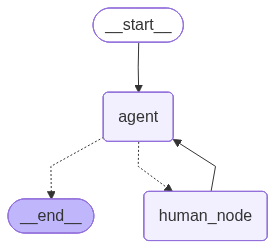

In [62]:
app = workflow.compile(checkpointer=memory)
app

In [63]:
thread_config = {"configurable": {"thread_id": "3"}}

In [64]:
input_data = {
    "messages": [
        SystemMessage(content="당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요."),
        HumanMessage(content="맛집 추천 좀 해줄래?")
    ]
}
from langchain.messages import SystemMessage, HumanMessage
app.invoke(input_data, config=thread_config)


[System] 사용자 질문 모드 진입. (허용 메뉴: ['한식', '중식', '일식', '양식', '분식'])


{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='9ed2c07b-9e4f-4e67-9c5a-e7dec916b49e'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='39e654f2-b804-4c1f-972d-1e45f6d71e55'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 783, 'prompt_tokens': 186, 'total_tokens': 969, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5ap7uIrgnE3kitucKwkbQrUPjwa', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce962-f364-7fc0-8b73-b20b990854d7-0', tool_calls=[{'name': 'ask_human', 'args': {'question

In [65]:
# 현재 Interrupt 상태 확인
snapshot = app.get_state(thread_config)
if snapshot.next:
    question = snapshot.tasks[0].interrupts[0].value
    print(f"\n⚠️ [Interrupt 발생] AI의 질문: {question}")


⚠️ [Interrupt 발생] AI의 질문: 맛집 추천 도와드릴게요! 위치와 메뉴 취향을 알려주시면 더 정확하게 골라드릴 수 있어요.

1) 위치: 동네나 도시를 알려주세요(예: 서울 강남구, 부산 해운대구 등).
2) 선호하는 메뉴/음식 종류: 한식, 중식, 일식, 양식, 해산물, 고기집 등 또는 특정 요리.
3) 예산 범위: 1인당 대략 어느 정도를 원하시나요? 예: 1~2만, 2~4만, 4만+ 등.
4) 분위기/상세 조건: 캐주얼/데이트/가성비 좋음/예약 필요 여부 등.
5) 인원수와 방문 시간대(있으면)도 알려주시면 좋습니다.


In [66]:
# 검증 실패 케이스: '신발 튀김'은 허용 카테고리에 없습니다.
# → human_validating_node의 while 루프에서 실패하고 재질문이 발생해야 합니다.
app.invoke(Command(resume="신발 튀김"), config=thread_config)


[System] 사용자 질문 모드 진입. (허용 메뉴: ['한식', '중식', '일식', '양식', '분식'])
 [Check] 사용자 입력값 검증 중: '신발 튀김'
X [Fail] 메뉴에 없는 요청입니다.


{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='9ed2c07b-9e4f-4e67-9c5a-e7dec916b49e'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='39e654f2-b804-4c1f-972d-1e45f6d71e55'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 783, 'prompt_tokens': 186, 'total_tokens': 969, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5ap7uIrgnE3kitucKwkbQrUPjwa', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce962-f364-7fc0-8b73-b20b990854d7-0', tool_calls=[{'name': 'ask_human', 'args': {'question

In [67]:
# 재질문 내용 확인 (에러 메시지가 포함된 프롬프트)
snapshot = app.get_state(thread_config)
print(f"⚠️ [재질문] 내용: {snapshot.tasks[0].interrupts[0].value}")

⚠️ [재질문] 내용: 죄송합니다. '신발 튀김'은(는) 추천해드릴 수 없습니다.
가능한 메뉴는 ['한식', '중식', '일식', '양식', '분식'] 입니다. 다시 말씀해주세요.


In [68]:
# 검증 통과 케이스: '양식'은 허용 카테고리에 포함됩니다.
result = app.invoke(Command(resume="양식"), config=thread_config)


[System] 사용자 질문 모드 진입. (허용 메뉴: ['한식', '중식', '일식', '양식', '분식'])
 [Check] 사용자 입력값 검증 중: '신발 튀김'
X [Fail] 메뉴에 없는 요청입니다.
 [Check] 사용자 입력값 검증 중: '양식'
 [Pass] 유효한 메뉴입니다.

[System] 사용자 질문 모드 진입. (허용 메뉴: ['한식', '중식', '일식', '양식', '분식'])


In [69]:
result['messages'][-1].content

''

In [70]:
result

{'messages': [SystemMessage(content='당신은 맛집 추천 비서입니다. 위치와 메뉴를 모르면 반드시 도구를 호출해 물어보세요.', additional_kwargs={}, response_metadata={}, id='9ed2c07b-9e4f-4e67-9c5a-e7dec916b49e'),
  HumanMessage(content='맛집 추천 좀 해줄래?', additional_kwargs={}, response_metadata={}, id='39e654f2-b804-4c1f-972d-1e45f6d71e55'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 783, 'prompt_tokens': 186, 'total_tokens': 969, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5ap7uIrgnE3kitucKwkbQrUPjwa', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce962-f364-7fc0-8b73-b20b990854d7-0', tool_calls=[{'name': 'ask_human', 'args': {'question

---
# 4. Command with Goto

## 개념 설명

노드 함수가 `Command(goto=노드명)`을 반환하면  
그래프에 미리 엣지를 정의하지 않아도 **실행 시점에 동적으로** 다음 노드를 지정할 수 있습니다.

```python
# 노드 함수 내부에서 직접 경로 결정
return Command(
    update={"messages": [...]},  # 상태 업데이트 (선택)
    goto="booking"               # 즉시 이동할 노드
)
```

### add_conditional_edges vs Command(goto)

| 구분 | add_conditional_edges | Command(goto) |
|------|----------------------|---------------|
| 정의 시점 | 그래프 빌드 타임 | 런타임 (실행 중) |
| 유연성 | 정해진 경우의 수 | 완전히 동적 |
| 가독성 | 그래프 구조가 명확 | 노드 내부에 로직 포함 |


### Model & Tool 정의

In [162]:
from langchain.chat_models import init_chat_model
model = init_chat_model("gpt-5-nano")

### State 정의

In [163]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    selected_menu: str  # 현재 추천된 메뉴를 저장합니다.

### Node 정의

In [164]:
# [Node 1] 메뉴 추천 노드
def recommender_node(state: ChatState):
    """
    최초 실행 시 A코스를 추천합니다.
    이미 A코스가 거절당한 경우(selected_menu == 'A코스') B코스로 바꿉니다.
    """
    last_menu = state.get("selected_menu")

    # 이전에 A코스가 저장되어 있다면 → 거절당하고 다시 온 것
    if last_menu == "A 코스 (20만원)":
        print("\n🍣 [Recommender] 그렇다면. 실속형 'B 코스 (8만원)'을 추천합니다.")
        return {"selected_menu": "B 코스 (8만원)"}

    # 기본(최초) 추천: A코스
    else:
        print("\n🍣 [Recommender] 쉐프 추천: 'A 코스 (20만원)'")
        return {"selected_menu": "A 코스 (20만원)"}

In [165]:
# [Node 2] 승인/거절 판단 노드 (Router 역할 겸임)
def human_approval_node(state: ChatState):
    """
    사용자의 승인 여부에 따라 Command(goto=...)로 즉시 경로를 결정합니다.
    - 승인(yes) → booking 노드로 점프
    - 거절(no)  → recommender 노드로 다시 보냄
    """
    menu = state["selected_menu"]

    print(f"\n 🚨 [Approval] '{menu}'은(는) 고가이므로 승인이 필요합니다.")

    # Interrupt: 사용자 확인 요청
    approved = interrupt(f" '{menu}' 예약을 진행하시겠습니까? (yes/no)")

    # Command(goto=...) 로 즉시 다음 노드 지정
    if approved == "yes":
        print(" ➡️ [Decision] 승인됨 -> 예약 확정으로 이동")
        return Command(
            update={"messages": ["사용자가 예약을 승인했습니다."]},
            goto="booking"  # booking_node로 즉시 점프!
        )
    else:
        print(" ➡️ [Decision] 거절됨 -> 다시 추천받으러 이동")
        return Command(
            update={"messages": ["사용자가 거절했습니다. 다른 메뉴를 찾습니다."]},
            goto="recommender"  # recommender_node로 즉시 점프!
        )

In [166]:
# [Node 3] 예약 확정 노드 (승인 시 이동)
def booking_node(state: ChatState):
    menu = state["selected_menu"]
    print(f"\n✅ [Booking] '{menu}' 예약이 확정되었습니다! (문자 발송 완료)")
    return {"messages": [f"'{menu}' 예약 완료"]}

### 그래프 생성

In [167]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(ChatState)

workflow.add_node("recommender", recommender_node)
workflow.add_node("approval", human_approval_node)
workflow.add_node("booking", booking_node)

In [168]:
# 기본 흐름: START → recommender → approval
# approval 이후의 경로는 Command(goto=...)로 동적으로 결정됩니다.
workflow.add_edge(START, "recommender")
workflow.add_edge("recommender", "approval")

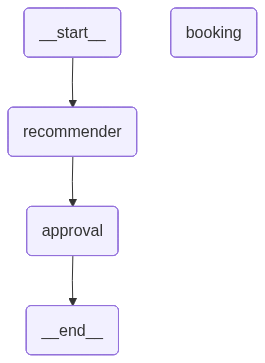

In [169]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)
app

In [170]:
config = {"configurable": {"thread_id": "goto-demo"}}

In [171]:
# 실행 시작: A코스 추천 → 승인 대기 Interrupt 발생
app.invoke({"messages": [HumanMessage(content="예약해줘")]}, config=config)


🍣 [Recommender] 쉐프 추천: 'A 코스 (20만원)'

 🚨 [Approval] 'A 코스 (20만원)'은(는) 고가이므로 승인이 필요합니다.


{'messages': [HumanMessage(content='예약해줘', additional_kwargs={}, response_metadata={}, id='b9493c6c-3b59-4d9f-a68b-20c45e732206')],
 'selected_menu': 'A 코스 (20만원)',
 '__interrupt__': [Interrupt(value=" 'A 코스 (20만원)' 예약을 진행하시겠습니까? (yes/no)", id='6632e61d682369d57a02c4c6704d83b4')]}

In [172]:
snapshot = app.get_state(config)
print(f"⚠️ 대기 중: {snapshot.tasks[0].interrupts[0].value}")

⚠️ 대기 중:  'A 코스 (20만원)' 예약을 진행하시겠습니까? (yes/no)


In [173]:
# 'no' 응답: Command(goto='recommender')가 실행되어 B코스를 추천받습니다.
app.invoke(Command(resume="no"), config=config)


 🚨 [Approval] 'A 코스 (20만원)'은(는) 고가이므로 승인이 필요합니다.
 ➡️ [Decision] 거절됨 -> 다시 추천받으러 이동

🍣 [Recommender] 그렇다면. 실속형 'B 코스 (8만원)'을 추천합니다.

 🚨 [Approval] 'B 코스 (8만원)'은(는) 고가이므로 승인이 필요합니다.


{'messages': [HumanMessage(content='예약해줘', additional_kwargs={}, response_metadata={}, id='b9493c6c-3b59-4d9f-a68b-20c45e732206'),
  HumanMessage(content='사용자가 거절했습니다. 다른 메뉴를 찾습니다.', additional_kwargs={}, response_metadata={}, id='71b0f9be-721a-4acc-a4ee-3245e5ed17fd')],
 'selected_menu': 'B 코스 (8만원)',
 '__interrupt__': [Interrupt(value=" 'B 코스 (8만원)' 예약을 진행하시겠습니까? (yes/no)", id='c7719d43cb8385c929b732ef0de64a5e')]}

In [174]:
snapshot = app.get_state(config)
print(f"{snapshot.tasks[0].interrupts[0].value}")

 'B 코스 (8만원)' 예약을 진행하시겠습니까? (yes/no)


In [175]:
# 'yes' 응답: Command(goto='booking')가 실행되어 예약이 확정됩니다.
result = app.invoke(Command(resume="yes"), config=config)


 🚨 [Approval] 'B 코스 (8만원)'은(는) 고가이므로 승인이 필요합니다.
 ➡️ [Decision] 승인됨 -> 예약 확정으로 이동

✅ [Booking] 'B 코스 (8만원)' 예약이 확정되었습니다! (문자 발송 완료)


In [176]:
result['messages'][-1].content

"'B 코스 (8만원)' 예약 완료"

In [177]:
result

{'messages': [HumanMessage(content='예약해줘', additional_kwargs={}, response_metadata={}, id='b9493c6c-3b59-4d9f-a68b-20c45e732206'),
  HumanMessage(content='사용자가 거절했습니다. 다른 메뉴를 찾습니다.', additional_kwargs={}, response_metadata={}, id='71b0f9be-721a-4acc-a4ee-3245e5ed17fd'),
  HumanMessage(content='사용자가 예약을 승인했습니다.', additional_kwargs={}, response_metadata={}, id='8be53572-e35e-4076-9c08-b299b6c9b70d'),
  HumanMessage(content="'B 코스 (8만원)' 예약 완료", additional_kwargs={}, response_metadata={}, id='0ced0b90-ad20-422b-9691-89a32d0e7771')],
 'selected_menu': 'B 코스 (8만원)'}

---
# 4-실습. Command with Goto (실습)

아래 섹션들을 직접 구현해보세요.

### Model & Tool 정의


### State 정의

### Node 정의

### 그래프 생성

---
# 5. Subgraph

## 개념 설명

Subgraph는 **그래프 안의 그래프** 패턴입니다.  
복잡한 시스템을 부서(모듈)별로 분리하여 각자의 워크플로우를 독립적으로 관리합니다.

### 두 가지 연결 방식

| 방식 | 코드 | 특징 |
|------|------|------|
| **State 공유** | `add_node("이름", 컴파일된_subgraph)` | 부모/자식이 동일 State 사용 |
| **State 분리** | 노드 함수 안에서 `subgraph.invoke(...)` | 독립 State → 직접 매핑 필요 |

```
[State 공유 방식]
Parent Graph ──add_node("kitchen", kitchen_subgraph)──▶ Subgraph 실행
              (상태 자동 전달)

[State 분리 방식]
Parent Graph ── bridge_node() ──▶ child.invoke(매핑된_입력)
              (수동 매핑)        ──▶ 결과를 Parent State로 수동 저장
```


### Model & Tool 정의

In [87]:
from langchain.chat_models import init_chat_model
model = init_chat_model("gpt-5-nano")

### State 정의

In [88]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

# 부모-자식 그래프가 공유하는 통합 State
class ReservationState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    menu: str           # 선택된 메뉴
    price: int          # 가격
    status: str         # 현재 상태 (예: 'confirmed', 'cancelled')
    chef_name: str      # 배정된 쉐프 (주방 Subgraph에서 채워짐)
    cooking_time: str   # 예상 조리 시간 (주방 Subgraph에서 채워짐)

### Child Graph (주방 시스템)

In [89]:
# ─── 주방 Subgraph 노드 1: 재료 확인 ───
def check_ingredients(state: ReservationState):
    print(f"\n   🍳 [주방/재료팀] '{state['menu']}' 재료 재고 확인 중...")
    # (실제 로직 생략: 항상 재료가 있다고 가정)
    return {"status": "ok"}

In [90]:
# ─── 주방 Subgraph 노드 2: 쉐프 배정 ───
def assign_chef(state: ReservationState):
    menu = state['menu']
    # 메뉴에 따라 다른 쉐프를 배정합니다.
    if "오마카세" in menu:
        chef = "Master Jiro"
        time = "40분"
    else:
        chef = "Chef Kim"
        time = "20분"

    print(f"   👨‍🍳 [주방/인사팀] {chef} 쉐프 배정 완료 (예상 소요: {time})")
    return {"chef_name": chef, "cooking_time": time, "status": "cooking"}

In [91]:
# 주방 Subgraph 조립
kitchen_builder = StateGraph(ReservationState)
kitchen_builder.add_node("check_stock", check_ingredients)
kitchen_builder.add_node("assign_chef", assign_chef)

kitchen_builder.add_edge(START, "check_stock")
kitchen_builder.add_edge("check_stock", "assign_chef")
kitchen_builder.add_edge("assign_chef", END)

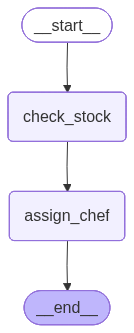

In [92]:
# 주방 그래프 컴파일
# 이 객체 자체를 부모 그래프의 '노드'로 등록할 수 있습니다.
kitchen_subgraph = kitchen_builder.compile()
kitchen_subgraph

### Parent Graph (메인 홀 시스템)

In [93]:
# ─── 부모 그래프 노드 1: 메뉴 추천 ───
def menu_recommender(state: ReservationState):
    last_msg = state["messages"][-1].content if state["messages"] else ""

    # 사용자 메시지에 '비싸' 또는 '부담'이 있으면 B코스 추천
    if "비싸" in last_msg or "부담" in last_msg:
        proposal = "B코스 (런치 스페셜)"
        price = 80000
        msg = f"🍣 부담 없는 '{proposal} ({price:,}원)'은 어떠신가요?"
    else:
        proposal = "A코스 (쉐프 오마카세)"
        price = 150000
        msg = f"🍣 시그니처 '{proposal} ({price:,}원)'를 추천합니다."

    return {"menu": proposal, "price": price, "messages": [msg]}

In [94]:
from typing import Literal
from pydantic import BaseModel, Field

# 사용자 의도를 구조화하여 추출합니다 (Structured Output)
class UserIntent(BaseModel):
    action: Literal["confirm", "change", "cancel"] = Field(
        description="확정, 변경, 취소 판단"
    )

In [95]:
# with_structured_output: LLM 응답을 UserIntent 객체로 자동 파싱합니다.
intent_analyzer = model.with_structured_output(UserIntent)

In [96]:
# ─── 부모 그래프 노드 2: 고객 의사 확인 (Agentic Router) ───
def customer_confirm_node(state: ReservationState):
    """
    1. Interrupt로 고객 의사를 물어봅니다.
    2. LLM으로 고객 답변의 의도(confirm/change/cancel)를 분석합니다.
    3. Command(goto=...)로 의도에 맞는 노드로 즉시 이동합니다.
    """
    menu = state['menu']
    price = state['price']

    print(f"\n🔴 [System]: 고객 의사 확인 중 (Interrupt)")
    user_input = interrupt(f"'{menu}' ({price:,}원)으로 하시겠습니까?")
    print(f"▶️ [User Input]: \"{user_input}\"")

    # LLM으로 의도 분석
    analysis = intent_analyzer.invoke(f"제안: {menu}, 답변: {user_input}")
    print(f"🧠 [AI Router]: 의도='{analysis.action}'")

    if analysis.action == "confirm":
        # [핵심] 'kitchen'으로 보내면 → 연결된 Subgraph가 실행됩니다.
        return Command(
            update={"messages": [HumanMessage(content=user_input)]},
            goto="kitchen"  # kitchen_subgraph로 점프!
        )
    elif analysis.action == "change":
        return Command(
            update={"messages": [HumanMessage(content=user_input)]},
            goto="recommender"  # 다시 메뉴 추천으로
        )
    else:
        return Command(
            update={"messages": [HumanMessage(content=user_input)]},
            goto="cancel"  # 취소 처리로
        )

In [97]:
# ─── 부모 그래프 노드 3: 취소 처리 ───
def cancel_node(state: ReservationState):
    print(f"\n👋 [카운터]: 예약 종료.")
    return {"status": "cancelled"}

In [98]:
# ─── 부모 그래프 조립 ───
parent_builder = StateGraph(ReservationState)

parent_builder.add_node("recommender", menu_recommender)
parent_builder.add_node("confirm", customer_confirm_node)
parent_builder.add_node("cancel", cancel_node)

# ★ 컴파일된 Subgraph를 '노드'로 등록합니다. ★
# 이렇게 하면 State를 공유하고, Command(goto='kitchen')으로 접근 가능합니다.
parent_builder.add_node("kitchen", kitchen_subgraph)

In [99]:
# 기본 엣지 등록
parent_builder.add_edge(START, 'recommender')
parent_builder.add_edge('recommender', 'confirm')
parent_builder.add_edge('kitchen', END)  # 주방 처리 완료 후 종료

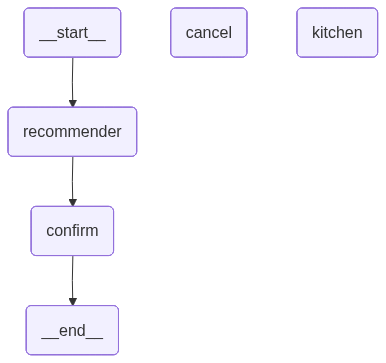

In [100]:
checkpointer = InMemorySaver()
app = parent_builder.compile(checkpointer=checkpointer)
app

### 실행

In [101]:
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨김

In [102]:
config = {"configurable": {"thread_id": "subgraph-demo-1"}}

In [103]:
# 실행 1: 기본 추천 (A코스) → 승인 대기
app.invoke({"messages": []}, config=config)


🔴 [System]: 고객 의사 확인 중 (Interrupt)


{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='b1b53106-deee-41c3-9dda-bce03582791f')],
 'menu': 'A코스 (쉐프 오마카세)',
 'price': 150000,
 '__interrupt__': [Interrupt(value="'A코스 (쉐프 오마카세)' (150,000원)으로 하시겠습니까?", id='3ed557b201c02478e0cbf395d5a60645')]}

In [104]:
# '좋아요'로 승인 → AI가 'confirm' 의도 감지 → kitchen subgraph 실행
user_response = "좋아요, 그걸로 주세요."
result = app.invoke(Command(resume=user_response), config=config)


🔴 [System]: 고객 의사 확인 중 (Interrupt)
▶️ [User Input]: "좋아요, 그걸로 주세요."
🧠 [AI Router]: 의도='confirm'

   🍳 [주방/재료팀] 'A코스 (쉐프 오마카세)' 재료 재고 확인 중...
   👨‍🍳 [주방/인사팀] Master Jiro 쉐프 배정 완료 (예상 소요: 40분)


In [105]:
result

{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='b1b53106-deee-41c3-9dda-bce03582791f'),
  HumanMessage(content='좋아요, 그걸로 주세요.', additional_kwargs={}, response_metadata={}, id='4e17e9ff-57e6-442f-ae34-0c87de65d1f6')],
 'menu': 'A코스 (쉐프 오마카세)',
 'price': 150000,
 'status': 'cooking',
 'chef_name': 'Master Jiro',
 'cooking_time': '40분'}

In [106]:
# 최종 결과 확인: chef_name은 kitchen subgraph에서 생성된 정보입니다.
print(f"메뉴: {result['menu']}")
print(f"상태: {result['status']}")
print(f"담당 쉐프: {result.get('chef_name')}")

메뉴: A코스 (쉐프 오마카세)
상태: cooking
담당 쉐프: Master Jiro


In [107]:
config = {"configurable": {"thread_id": "subgraph-demo-2"}}

In [108]:
# 실행 2: 기본 추천 (A코스) → 거절 → B코스 추천 → 승인 흐름
app.invoke({"messages": []}, config=config)


🔴 [System]: 고객 의사 확인 중 (Interrupt)


{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='f05b59ee-dcbe-4b20-8d5f-8415c2bb7a57')],
 'menu': 'A코스 (쉐프 오마카세)',
 'price': 150000,
 '__interrupt__': [Interrupt(value="'A코스 (쉐프 오마카세)' (150,000원)으로 하시겠습니까?", id='bd88f805d8e724675c130a9412c607ba')]}

In [109]:
# '너무 비싸요' → AI가 'change' 의도 감지 → recommender 노드로 이동
user_response = "아니요.. 너무 비싸요."
result = app.invoke(Command(resume=user_response), config=config)


🔴 [System]: 고객 의사 확인 중 (Interrupt)
▶️ [User Input]: "아니요.. 너무 비싸요."
🧠 [AI Router]: 의도='change'

🔴 [System]: 고객 의사 확인 중 (Interrupt)


In [110]:
result

{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='f05b59ee-dcbe-4b20-8d5f-8415c2bb7a57'),
  HumanMessage(content='아니요.. 너무 비싸요.', additional_kwargs={}, response_metadata={}, id='261b8185-eb18-4463-9c9d-f38cfc355e27'),
  HumanMessage(content="🍣 부담 없는 'B코스 (런치 스페셜) (80,000원)'은 어떠신가요?", additional_kwargs={}, response_metadata={}, id='72030417-ec34-4e7f-80a8-c9d18c30a142')],
 'menu': 'B코스 (런치 스페셜)',
 'price': 80000,
 '__interrupt__': [Interrupt(value="'B코스 (런치 스페셜)' (80,000원)으로 하시겠습니까?", id='45db8453dcd9c6661fad4f1c6801976b')]}

In [111]:
# B코스 승인
user_response = "그렇게 할게요."
final_result = app.invoke(Command(resume=user_response), config=config)


🔴 [System]: 고객 의사 확인 중 (Interrupt)
▶️ [User Input]: "그렇게 할게요."
🧠 [AI Router]: 의도='confirm'

   🍳 [주방/재료팀] 'B코스 (런치 스페셜)' 재료 재고 확인 중...
   👨‍🍳 [주방/인사팀] Chef Kim 쉐프 배정 완료 (예상 소요: 20분)


In [112]:
final_result

{'messages': [HumanMessage(content="🍣 시그니처 'A코스 (쉐프 오마카세) (150,000원)'를 추천합니다.", additional_kwargs={}, response_metadata={}, id='f05b59ee-dcbe-4b20-8d5f-8415c2bb7a57'),
  HumanMessage(content='아니요.. 너무 비싸요.', additional_kwargs={}, response_metadata={}, id='261b8185-eb18-4463-9c9d-f38cfc355e27'),
  HumanMessage(content="🍣 부담 없는 'B코스 (런치 스페셜) (80,000원)'은 어떠신가요?", additional_kwargs={}, response_metadata={}, id='72030417-ec34-4e7f-80a8-c9d18c30a142'),
  HumanMessage(content='그렇게 할게요.', additional_kwargs={}, response_metadata={}, id='4a9b2037-aaa4-48da-8ea4-1ac383dcae11')],
 'menu': 'B코스 (런치 스페셜)',
 'price': 80000,
 'status': 'cooking',
 'chef_name': 'Chef Kim',
 'cooking_time': '20분'}

In [113]:
print(f"메뉴: {final_result['menu']}")
print(f"상태: {final_result['status']}")
print(f"담당 쉐프: {final_result.get('chef_name')} (Subgraph에서 생성된 정보!)")

메뉴: B코스 (런치 스페셜)
상태: cooking
담당 쉐프: Chef Kim (Subgraph에서 생성된 정보!)


---
# 6. State 분리 Subgraph

## 개념 설명

부모와 자식이 **다른 State**를 사용해야 할 때는  
노드 함수 안에서 `subgraph.invoke()`를 직접 호출하고  
입/출력 데이터를 **수동으로 매핑**합니다.

```
Parent State (RestaurantState)
    menu, customer_address, final_status

         ↕ 수동 매핑 (Bridge Node)

Child State (DeliveryState)
    address, package_info, delivery_status
```

### 언제 쓰나요?
- 외부 서비스(배달 시스템, 결제 시스템)를 연동할 때
- 각 부서가 완전히 독립된 데이터 구조를 가져야 할 때
- 보안상 상태를 공유하면 안 될 때


## Child Graph
### State 정의

In [114]:
from typing_extensions import TypedDict

# 배달 업체만의 독립적인 State (외부 시스템)
class DeliveryState(TypedDict):
    address: str          # 배달 주소
    package_info: str     # 배달 물품 정보
    delivery_status: str  # 배달 상태

### Node 정의

In [115]:
# ─── 배달 Subgraph 노드 1: 픽업 ───
def pickup_package(state: DeliveryState):
    print(f"\n   🛵 [배달업체] 픽업 완료! (물품: {state['package_info']})")
    return {"delivery_status": "picked_up"}

In [116]:
# ─── 배달 Subgraph 노드 2: 배송 ───
def deliver_to_customer(state: DeliveryState):
    print(f"   🔔 [배달업체] {state['address']}로 배송 중... 띵동! 배달 완료.")
    return {"delivery_status": "delivered"}

### 그래프 생성

In [117]:
delivery_builder = StateGraph(DeliveryState)

delivery_builder.add_node("pickup", pickup_package)
delivery_builder.add_node("deliver", deliver_to_customer)

delivery_builder.add_edge(START, "pickup")
delivery_builder.add_edge("pickup", "deliver")
delivery_builder.add_edge("deliver", END)

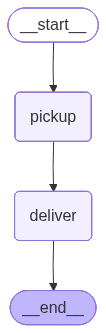

In [118]:
# 하위 그래프 컴파일 (이 자체를 함수처럼 invoke()할 수 있습니다)
delivery_graph = delivery_builder.compile()
delivery_graph

## Parent Graph
### State 정의

In [119]:
from langchain.messages import AnyMessage
from langgraph.graph.message import add_messages

# 레스토랑(부모) 시스템의 State
# DeliveryState와는 완전히 다른 구조입니다.
class RestaurantState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    menu: str                # 주문된 메뉴 (= delivery의 package_info)
    customer_address: str    # 고객 주소 (= delivery의 address)
    final_status: str        # 최종 배달 상태 (delivery_status에서 받아옴)

### Node 정의

In [120]:
# ─── 부모 그래프 노드 1: 조리 ───
def cook_food(state: RestaurantState):
    print(f"\n👨‍🍳 [주방] '{state['menu']}' 조리 완료! 포장했습니다.")
    return {"messages": ["조리 완료"]}

In [121]:
# ─── 부모 그래프 노드 2: 배달 브릿지 (Bridge) ───
def call_delivery_service(state: RestaurantState):
    """
    State 분리 방식의 핵심 패턴입니다.

    1. Parent State의 필드를 Child State 형식으로 '변환(매핑)'합니다.
    2. invoke()로 Child 그래프를 독립적으로 실행합니다.
    3. 결과를 다시 Parent State 형식으로 '변환'하여 반환합니다.
    """
    print("\n📞 [매니저] 배달 업체 호출 중...")

    # ── Step 1: Parent 필드 → Child 필드로 매핑 ──
    delivery_input = {
        "address": state["customer_address"],
        "package_info": state["menu"]  # 'menu'를 'package_info'로 이름 바꿔서 전달
    }

    # ── Step 2: 독립 실행 (부모와 자식은 State를 공유하지 않음) ──
    delivery_result = delivery_graph.invoke(delivery_input)

    # ── Step 3: Child 결과 → Parent State로 매핑 ──
    final_status = delivery_result["delivery_status"]
    print(f"📞 [매니저] 배달 업체 응답 수신: {final_status}")

    return {"final_status": final_status}

### 그래프 생성

In [122]:
parent_builder = StateGraph(RestaurantState)

parent_builder.add_node("kitchen", cook_food)
parent_builder.add_node("delivery_manager", call_delivery_service)

parent_builder.add_edge(START, "kitchen")
parent_builder.add_edge("kitchen", "delivery_manager")
parent_builder.add_edge("delivery_manager", END)

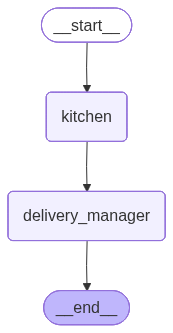

In [123]:
# State 분리 방식은 checkpointer 없이도 동작합니다.
app = parent_builder.compile()
app

### 실행

In [124]:
inputs = {
    "menu": "특선 초밥 세트",
    "customer_address": "서울시 강남구 역삼동 123",
    "messages": []
}

In [125]:
result = app.invoke(inputs)


👨‍🍳 [주방] '특선 초밥 세트' 조리 완료! 포장했습니다.

📞 [매니저] 배달 업체 호출 중...

   🛵 [배달업체] 픽업 완료! (물품: 특선 초밥 세트)
   🔔 [배달업체] 서울시 강남구 역삼동 123로 배송 중... 띵동! 배달 완료.
📞 [매니저] 배달 업체 응답 수신: delivered


In [126]:
result

{'messages': [HumanMessage(content='조리 완료', additional_kwargs={}, response_metadata={}, id='d585ab11-2689-49c0-9b94-2aa249e8a702')],
 'menu': '특선 초밥 세트',
 'customer_address': '서울시 강남구 역삼동 123',
 'final_status': 'delivered'}

---
# Subgraph 실습

## 📝 [실습 1] "여행용 환전 지갑" 만들기

### 배경
여행 가이드 앱을 만들고 있습니다.  
사용자가 "100달러 환전해줘"라고 말하면, 외부 은행 시스템(Subgraph)에 요청하여 환전을 처리해야 합니다.

### 제약 사항
1. 여행 앱(Parent)과 은행(Child)은 서로 다른 보안 시스템을 쓰기 때문에 State를 공유하지 않습니다.
2. 따라서 `add_node(subgraph)` 방식이 아닌, 노드 함수 안에서 `invoke()`를 사용해야 합니다.
3. Parent State의 `request_amount`를 Child State의 `usd_amount`로 변환해서 넘겨야 합니다.

### ✅ 요구사항
`exchange_bridge_node` 함수를 완성하세요:
1. Parent State에서 `request_amount`를 가져옵니다.
2. Bank State 형식(`{'usd_amount': ...}`)으로 변환합니다.
3. `bank_graph`를 `invoke()` 합니다.
4. 결과의 `krw_result`를 Parent State의 `balance_krw`에 넣어 반환합니다.


In [127]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# ==========================================
# 1. [Child] 외부 은행 시스템 (수정 금지)
# ==========================================
class BankState(TypedDict):
    usd_amount: int   # 입금된 달러
    krw_result: int   # 환전된 원화
    receipt: str      # 영수증

def calculate_exchange(state: BankState):
    rate = 1400  # 환율: 1달러 = 1,400원 가정
    krw = state['usd_amount'] * rate
    print(f"   🏦 [은행] ${state['usd_amount']} -> {krw}원 환전 처리 중...")
    return {
        "krw_result": krw,
        "receipt": f"[영수증] {state['usd_amount']} USD -> {krw} KRW"
    }

bank_builder = StateGraph(BankState)
bank_builder.add_node("calc", calculate_exchange)
bank_builder.add_edge(START, "calc")
bank_builder.add_edge("calc", END)
bank_graph = bank_builder.compile()

# ==========================================
# 2. [Parent] 여행 가이드 앱
# ==========================================
class TravelState(TypedDict):
    request_amount: int  # 사용자가 요청한 달러
    balance_krw: int     # 나의 원화 지갑 잔액
    status: str

def request_node(state: TravelState):
    amount = state['request_amount']
    print(f"\n✈️ [가이드] ${amount} 환전을 위해 은행에 연결합니다.")
    return {"status": "requesting"}

# ★ [미션] 여기가 문제입니다! ★
def exchange_bridge_node(state: TravelState):
    """
    1. Parent State에서 'request_amount'를 가져오세요.
    2. Bank State 양식({'usd_amount': ...})에 맞춰 데이터를 만드세요.
    3. bank_graph를 invoke() 하세요.
    4. 결과('krw_result')를 가져와서 Parent State의 'balance_krw'에 넣어서 반환하세요.
    """
    # (여기에 코드를 작성하세요)
    pass

# ==========================================
# 3. 그래프 조립 (수정 금지)
# ==========================================
app_builder = StateGraph(TravelState)
app_builder.add_node("guide", request_node)
app_builder.add_node("bank_bridge", exchange_bridge_node)

app_builder.add_edge(START, "guide")
app_builder.add_edge("guide", "bank_bridge")
app_builder.add_edge("bank_bridge", END)

app = app_builder.compile()

# 실행
print("### 환전 요청 실행 ###")
result = app.invoke({"request_amount": 100, "balance_krw": 0, "status": "start"})

print(f"\n🎉 [최종 결과] 내 지갑 잔액: {result['balance_krw']}원")

### 환전 요청 실행 ###

✈️ [가이드] $100 환전을 위해 은행에 연결합니다.

🎉 [최종 결과] 내 지갑 잔액: 0원


In [128]:
# ★ [정답] ★
def exchange_bridge_node(state: TravelState):
    # 1. Parent State에서 정보 꺼내기
    my_request = state['request_amount']

    # 2. Child State 양식으로 데이터 포장 (Mapping)
    #    Parent의 'request_amount' → Child의 'usd_amount'
    bank_input = {"usd_amount": my_request}

    # 3. 외부 그래프 독립 호출 (invoke 결과만 반환)
    bank_output = bank_graph.invoke(bank_input)

    # 4. 결과를 Parent State에 기록
    #    Child의 'krw_result' → Parent의 'balance_krw'
    exchanged_money = bank_output["krw_result"]
    print(f"✈️ [가이드] 은행에서 {exchanged_money}원을 받아왔습니다.")

    return {
        "balance_krw": exchanged_money,
        "status": "completed"
    }

---
## 📝 [실습 2] AI 뉴스레터 편집국

### 목표
주제만 입력하면 기획 → 검색 → 작성 → **인간 편집장 검수(Review)** → 발행까지  
자동으로 처리하는 시스템을 구축합니다.

### 구조 (Architecture)
- **Parent Graph (편집국)**: 전체 흐름 관장, 인간 편집장과의 소통
- **Subgraph (제작팀)**: 리서처와 작가 에이전트

### 워크플로우
1. 사용자가 주제(Topic) 입력
2. **제작팀(Subgraph)** 이 초안 작성
3. **편집장(Parent)** 에게 Interrupt — 초안 검수 요청
4. **승인(Approve)**: 발행 후 종료
5. **거절(Reject)**: 피드백 입력 → 제작팀으로 재전송 (`Command` 사용)
6. **수정(Revision)**: 제작팀이 피드백을 반영하여 원고 수정 (State 유지)


In [129]:
from typing import Annotated, TypedDict, List, Literal, Optional
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command

# ====================================================
# 1. 공유 State 정의
# ====================================================
class NewsState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    topic: str                   # 뉴스레터 주제
    research_data: Optional[str] # 리서처가 수집한 자료
    draft: Optional[str]         # 작가가 작성한 초안
    feedback: Optional[str]      # 편집장의 피드백
    status: str                  # 현재 진행 상태

# gpt-5-nano 모델 사용
llm = ChatOpenAI(model="gpt-5-nano", temperature=0.7)

# ====================================================
# 2. [Subgraph] 콘텐츠 제작팀
# ====================================================

def researcher_node(state: NewsState):
    """주제에 대한 자료를 조사합니다. 피드백이 있으면 반영합니다."""
    topic = state["topic"]
    feedback = state.get("feedback")

    print(f"\n🔎 [Researcher] AI가 '{topic}' 자료를 조사하고 있습니다...")

    # 피드백 유무에 따라 다른 프롬프트 사용
    if feedback:
        query = f"주제: '{topic}'\n추가 지시사항(피드백): {feedback}\n\n위 내용을 반영하여 핵심 정보를 조사하세요."
        print(f"   ↳ (지시사항 반영 중: {feedback})")
    else:
        query = f"주제: '{topic}'\n\n위 주제에 대한 최신 트렌드와 핵심 사실 3가지를 요약해서 조사하세요."

    response = llm.invoke([
        SystemMessage(content="당신은 세계 최고의 IT 트렌드 리서처입니다. 팩트 기반으로 명확하게 요약하세요."),
        HumanMessage(content=query)
    ])

    return {"research_data": response.content}

def writer_node(state: NewsState):
    """조사 자료를 바탕으로 뉴스레터 초안을 작성합니다. 피드백이 있으면 반영합니다."""
    print(f"\n✍️ [Writer] AI가 뉴스레터 초안을 작성하고 있습니다...")

    data = state["research_data"]
    feedback = state.get("feedback")

    if feedback:
        prompt = f"""[지시사항]
        편집장의 피드백: \"{feedback}\"
        위 피드백을 철저히 반영하여, 아래 조사 자료를 바탕으로 뉴스레터를 '다시' 작성하세요.
        [조사 자료]
        {data}"""
    else:
        prompt = f"""[지시사항]
        아래 조사 자료를 바탕으로 독자들이 흥미를 느낄만한 뉴스레터 초안을 작성하세요.
        서론-본론-결론 구조를 갖추세요.
        [조사 자료]
        {data}"""

    response = llm.invoke([
        SystemMessage(content="당신은 베스트셀러 작가이자 뉴스레터 에디터입니다. 전문적이면서도 읽기 쉬운 톤을 유지하세요."),
        HumanMessage(content=prompt)
    ])

    return {"draft": response.content}

# Subgraph 조립
content_builder = StateGraph(NewsState)
content_builder.add_node("researcher", researcher_node)
content_builder.add_node("writer", writer_node)
content_builder.add_edge(START, "researcher")
content_builder.add_edge("researcher", "writer")
content_builder.add_edge("writer", END)
content_team = content_builder.compile()

# ====================================================
# 3. [Parent Graph] 편집국 (Human-in-the-loop)
# ====================================================

def human_review_node(state: NewsState):
    """편집장이 초안을 검토합니다. 승인 또는 피드백과 함께 거절합니다."""
    current_draft = state["draft"]

    print(f"\n🛑 [Editor-in-Chief] 초안 검수 (Interrupt)")
    print("=" * 60)
    print(f"[AI가 작성한 초안]\n\n{current_draft}")
    print("=" * 60)

    # 편집장 입력 대기 (Interrupt)
    review_input = interrupt("승인하려면 'ok', 수정하려면 '피드백'을 입력하세요.")
    print(f"▶️ [Editor Decision]: {review_input}")

    # 의사 결정에 따른 라우팅
    if review_input.lower() in ["ok", "승인", "yes"]:
        return Command(
            update={
                "status": "published",
                "messages": [HumanMessage(content="편집장 승인 완료")]
            },
            goto="publisher"  # 발행 노드로 이동
        )
    else:
        # 피드백을 State에 저장하고 제작팀으로 재전송
        return Command(
            update={
                "feedback": review_input,
                "messages": [HumanMessage(content=f"피드백: {review_input}")]
            },
            goto="content_team"  # Subgraph로 돌아가서 수정
        )

def publisher_node(state: NewsState):
    """승인된 뉴스레터를 최종 발행합니다."""
    print(f"\n🚀 [Publisher] 뉴스레터 발행 완료! (구독자에게 전송됨)")
    return {"status": "completed"}

# Parent Graph 조립
parent_builder = StateGraph(NewsState)
parent_builder.add_node("content_team", content_team)  # Subgraph를 노드로 등록!
parent_builder.add_node("reviewer", human_review_node)
parent_builder.add_node("publisher", publisher_node)

parent_builder.add_edge(START, "content_team")
parent_builder.add_edge("content_team", "reviewer")
parent_builder.add_edge("publisher", END)

checkpointer = InMemorySaver()
app = parent_builder.compile(checkpointer=checkpointer)

In [130]:
config = {"configurable": {"thread_id": "newsletter-prod-1"}}

# 주제 입력 → 제작팀 초안 작성 → 편집장 검수 대기
app.invoke({"topic": "2025년 생성형 AI 트렌드"}, config=config)


🔎 [Researcher] AI가 '2025년 생성형 AI 트렌드' 자료를 조사하고 있습니다...

✍️ [Writer] AI가 뉴스레터 초안을 작성하고 있습니다...

🛑 [Editor-in-Chief] 초안 검수 (Interrupt)
[AI가 작성한 초안]

제목: 2025년 생성형 AI 트렌드, 당신의 비즈니스를 바꿀 3가지 축

서론
생성형 AI의 속도와 영역은 계속 확장되고 있습니다. 엔터프라이즈부터 개발·창작 현장, 데이터 전략까지 변화의 파도가 한꺼번에 다가오고 있습니다. 이번 호는 2025년 트렌드를 바탕으로, 독자 여러분이 바로 활용할 수 있는 핵심 방향과 현실적 포인트를 담았습니다. 세 가지 트렌드와 그 뒤에 숨은 세 가지 핵심 사실을 따라가면, 내년 전략 수립에 든든한 길잡이가 될 것입니다.

본론

트렌드 1: 엔터프라이즈 AI의 전사적 인프라화 및 코파일럿 보편화
- 무엇이 바뀌나: AI 코파일럿이 기업의 핵심 시스템(ERP, CRM, 데이터 분석 등)의 기본 도구로 자리 잡고, 업무 프로세스 전반에 AI가 내재화됩니다.
- 조직에 미치는 영향: 운영 효율성 상승과 표준화된 AI 거버넌스 수요가 함께 증가합니다. AI 운영 체계가 대기업 중심에서 중소기업으로 확산되며, 비즈니스 의사결정과 운영 전반에 AI가 관여하는 구조가 정착합니다.
- 실행 포인트: 
  - MLOps와 모델 거버넌스, 비용 관리 체계를 표준화하고 도입 로드맵을 수립합니다.
  - 기존 시스템에 코파일럿 기능을 점진적으로 통합하는 파일럿 프로젝트를 시작합니다.
  - 데이터 품질과 변경 관리 체계를 강화해 생산성 효과를 확인합니다.

트렌드 2: 개발·창작 영역의 AI 도구화와 멀티모달 역량 강화
- 무엇이 바뀌나: 코드 생성, 문서화 자동화, 테스트 보조, 디자인/멀티모달 콘텐츠 생산 등 다양한 창작 활동에서 생성형 AI의 역할이 확대됩니다.
- 조직에 미치는 영향: RLHF(사람이 평가하는 학습) 등 평가·안정성 강화 메커니즘이 함께 발전하며 신뢰성 요구가 커집

{'messages': [],
 'topic': '2025년 생성형 AI 트렌드',
 'research_data': '다음은 2025년 생성형 AI 트렌드를 바탕으로 한 최신 전망의 요약입니다. 요청에 맞춰 3가지 핵심 트렌드와 이를 뒷받침하는 3가지 핵심 사실로 정리합니다.\n\n최신 트렌드 3가지\n- 트렌드 1: 엔터프라이즈 AI의 전사적 인프라화 및 코파일럿 보편화\n  - 기업의 업무 프로세스에 AI 코파일럿이 내재화되고, ERP·CRM·데이터 분석 등 핵심 시스템에 AI 기능이 기본 도구로 확산됩니다. 운영 효율성 제고와 표준화된 AI 거버넌스 수요가 함께 증가합니다.\n- 트렌드 2: 개발·창작 영역의 AI 도구화와 멀티모달 역량 강화\n  - 코드 생성, 문서화 자동화, 테스트 보조, 디자인/멀티모달 콘텐츠 생산 등 다양한 창작 활동에서 생성형 AI의 역할이 확대됩니다. RLHF 등 평가·안정성 강화 메커니즘이 함께 발전하며 신뢰성 요구가 커집니다.\n- 트렌드 3: 데이터 중심 전략, 합성 데이터와 프라이버시 기술의 주류화\n  - 데이터 수집의 한계와 규제에 대응해 합성 데이터, 프라이버시 보호 기술, 온-프렘/에지 배포가 중요한 전략 요소로 자리 잡습니다. 벡터 DB/RAG 같은 정보 검색 기반의 활용이 보편화됩니다.\n\n핵심 사실 3가지\n- 사실 1: 기업 운영의 핵심 인프라이브로 AI가 자리잡고, MLOps/모델 거버넌스와 비용 관리 체계가 표준으로 채택됩니다.\n  - 대기업을 중심으로 시작된 AI 운영 체계가 중소기업으로 확산되며, 생산성 도구를 넘어 비즈니스 의사결정과 운영 전반에 AI가 관여하는 구조가 정착하고 있습니다.\n- 사실 2: 데이터 전략의 핵심 축으로 합성 데이터와 안전·개인정보 보호 기술이 중요해집니다.\n  - 합성 데이터 활용과 프라이버시 보호 기술이 데이터 확보의 대안으로 떠오르고, RAG/지식 기반 시스템의 정확도와 안전성을 높이는 기반으로 작용합니다.\n- 사실 3: 안전성, 책임성, 규제 준수의 중요성

In [131]:
snapshot = app.get_state(config)
print(f"\n⚠️ 현재 단계: {snapshot.next}")


⚠️ 현재 단계: ('reviewer',)


In [132]:
# 거절: 피드백과 함께 제작팀으로 재전송
feedback_msg = "너무 딱딱해요. 좀 더 유머러스하고 친근한 말투로 바꿔주세요."

app.invoke(Command(resume=feedback_msg), config=config)


🛑 [Editor-in-Chief] 초안 검수 (Interrupt)
[AI가 작성한 초안]

제목: 2025년 생성형 AI 트렌드, 당신의 비즈니스를 바꿀 3가지 축

서론
생성형 AI의 속도와 영역은 계속 확장되고 있습니다. 엔터프라이즈부터 개발·창작 현장, 데이터 전략까지 변화의 파도가 한꺼번에 다가오고 있습니다. 이번 호는 2025년 트렌드를 바탕으로, 독자 여러분이 바로 활용할 수 있는 핵심 방향과 현실적 포인트를 담았습니다. 세 가지 트렌드와 그 뒤에 숨은 세 가지 핵심 사실을 따라가면, 내년 전략 수립에 든든한 길잡이가 될 것입니다.

본론

트렌드 1: 엔터프라이즈 AI의 전사적 인프라화 및 코파일럿 보편화
- 무엇이 바뀌나: AI 코파일럿이 기업의 핵심 시스템(ERP, CRM, 데이터 분석 등)의 기본 도구로 자리 잡고, 업무 프로세스 전반에 AI가 내재화됩니다.
- 조직에 미치는 영향: 운영 효율성 상승과 표준화된 AI 거버넌스 수요가 함께 증가합니다. AI 운영 체계가 대기업 중심에서 중소기업으로 확산되며, 비즈니스 의사결정과 운영 전반에 AI가 관여하는 구조가 정착합니다.
- 실행 포인트: 
  - MLOps와 모델 거버넌스, 비용 관리 체계를 표준화하고 도입 로드맵을 수립합니다.
  - 기존 시스템에 코파일럿 기능을 점진적으로 통합하는 파일럿 프로젝트를 시작합니다.
  - 데이터 품질과 변경 관리 체계를 강화해 생산성 효과를 확인합니다.

트렌드 2: 개발·창작 영역의 AI 도구화와 멀티모달 역량 강화
- 무엇이 바뀌나: 코드 생성, 문서화 자동화, 테스트 보조, 디자인/멀티모달 콘텐츠 생산 등 다양한 창작 활동에서 생성형 AI의 역할이 확대됩니다.
- 조직에 미치는 영향: RLHF(사람이 평가하는 학습) 등 평가·안정성 강화 메커니즘이 함께 발전하며 신뢰성 요구가 커집니다.
- 실행 포인트:
  - 개발 파이프라인에 AI 도구를 통해 생산성 향상을 측정하고, 품질 관리 프로세스를 보강합니다.
  - 멀티모달 콘텐츠(텍스트-이미지-음성 

{'messages': [HumanMessage(content='피드백: 너무 딱딱해요. 좀 더 유머러스하고 친근한 말투로 바꿔주세요.', additional_kwargs={}, response_metadata={}, id='117d16ef-95a5-4a30-8187-6748b5d8b624')],
 'topic': '2025년 생성형 AI 트렌드',
 'research_data': '좋아요. 2025년 생성형 AI 트렌드를 팩트에 근거해, 그러나 너무 딱딱하지 않게 친근하고 이해하기 쉽게 정리해볼게요.\n\n1) 2025년 핵심 트렌드 (요약)\n- Copilots가 표준이 된다\n  - 기업용 소프트웨어에 AI 챗봇/보조자가 기본으로 탑재되며, 문서 작성, 코드 작성, 데이터 분석, 의사결정 초안까지 AI가 바로 옆에서 돕는 시나리오가 일반화됩니다. 예: ERP/CRM, 협업 도구, BI 대시보드 등.\n\n- 멀티모달 AI와 AI 에이전트의 확산\n  - 텍스트를 넘어서 이미지, 음성, 비디오를 동시에 다루는 모델이 늘고, 툴사용/환경 제어까지 스스로 계획하고 실행하는 ‘에이전트’가 업무 프로세스에 직접 관여합니다.\n\n- 프라이버시 중심의 개인화\n  - 온디바이스 추론, 연합학습, 차등 프라이버시 등으로 데이터 소유권과 프라이버시를 해치지 않으면서도 개인 맞춤형 AI를 제공합니다. 기업은 데이터 주권을 더 강하게 주장하게 될 가능성이 큽니다.\n\n- 데이터 주도 AI의 부상(합성 데이터와 라벨링 자동화)\n  - 합성 데이터로 편향을 줄이고 라벨링 비용을 낮추며, 학습 데이터의 품질 관리가 더 쉬워집니다. 데이터 중심 AI에 대한 투자와 도구들이 확산됩니다.\n\n- 개발 생태계의 재편: 코드-생성-테스트-배포의 러프한 흐름이 자동화\n  - 코드 제너레이션, 자동 테스트, 자동 리팩토링, 배포 파이프라인의 AI 보조가 표준화됩니다. MLOps/DevOps의 협업이 더 빠르고 예측 가능해집니다.\n\n- 거버넌스와 규제의 강화\n  - 모델 책임성,

In [133]:
# 승인: 최종 발행
result = app.invoke(Command(resume="ok"), config=config)


🛑 [Editor-in-Chief] 초안 검수 (Interrupt)
[AI가 작성한 초안]

안녕하세요, 트렌드 팔로워 여러분. 이번 주에도 AI의 미래를 함께 살펴보려 합니다. 편집장님의 피드백대로 “딱딱함”은 벗어나고, 조금은 산뜻하고 친근한 톤으로 정리해 봤어요. 읽으면서 미소 지을 정도의 여유도 함께 담았습니다.

1) 2025년 핵심 트렌드 (쉽고 재밌게 요약)
- Copilots가 표준이 된다
  - 기업용 소프트웨어에 AI 챗봇/보조자가 기본 탑재. 문서 작성, 코드 작성, 데이터 분석, 의사결정 초안까지 AI가 바로 옆에서 돕는 시대가 일반화됩니다. 예: ERP/CRM, 협업 도구, BI 대시보드 등.

- 멀티모달 AI와 AI 에이전트의 확산
  - 텍스트만 보는 시대는 지났다. 이미지, 음성, 비디오를 동시에 다루는 모델이 늘고, 툴 사용까지 스스로 계획하고 실행하는 ‘에이전트’가 업무 프로세스에 직접 관여합니다.

- 프라이버시 중심의 개인화
  - 데이터는 여전히 회사의 자산이지만, 온디바이스 추론, 연합학습, 차등 프라이버시로 개인화도 지키는 방식이 돼요. 기업은 데이터 주권을 더 강하게 주장하는 쪽으로 무게가 기웁니다.

- 데이터 주도 AI의 부상 (합성 데이터와 라벨링 자동화)
  - 합성 데이터로 편향을 줄이고 라벨링 비용을 낮추며, 학습 데이터의 품질 관리가 쉬워집니다. 데이터 중심 AI에 대한 투자도 늘어나고 있죠.

- 개발 생태계의 재편: 자동화가 흐름의 기본
  - 코드 제너레이션, 자동 테스트, 자동 리팩토링, 배포 파이프라인의 AI 보조가 표준화됩니다. MLOps/DevOps의 협업도 더 빨라지고 예측 가능해져요.

- 거버넌스와 규제의 강화
  - 모델 책임성, 안전성, 데이터 사용 규정 준수, 감사 가능성 등 거버넌스 요소가 더 엄격해지며, 기업은 모델 리스크 관리 체계를 점검해야 합니다.

- 비용 최적화와 하드웨어의 진화
  - 효율적인 추론 기술, 모델 압축/지연 최소화, 특화 칩의 보급으로 총소유비용(TC

---
# 7. Multi-Agent (Supervisor - 중앙 집중형)

## 개념 설명

**Supervisor** 패턴은 중앙의 감독관(Supervisor)이  
팀원(Worker)들에게 작업을 지시하고, 완료 여부를 판단하는 구조입니다.

```
사용자 요청
    ↓
[Supervisor] ──→ [Researcher] → 조사 결과 → [Supervisor]
             ──→ [Writer]     → 작성 결과 → [Supervisor]
             ──→ FINISH
```

### 특징
- 모든 팀원이 **하나의 공유 State(messages)**를 통해 소통합니다.
- Supervisor가 전체 진행 상황을 파악하고 다음 지시를 내립니다.
- 팀원은 작업 후 항상 Supervisor로 돌아갑니다: `Command(goto="supervisor")`

### 참고 문서
- [LangGraph Multi-Agent 공식 문서](https://docs.langchain.com/oss/python/langchain/multi-agent)


## Model 정의

In [134]:
from langchain.chat_models import init_chat_model
model = init_chat_model("gpt-5-nano")

## State 정의

In [135]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class TeamState(TypedDict):
    # 팀원들이 공유하는 메시지 기록
    # Researcher, Writer의 결과가 모두 이 리스트에 누적됩니다.
    messages: Annotated[list[AnyMessage], add_messages]

In [136]:
from pydantic import BaseModel, Field
from typing import Literal

# 감독관이 내릴 수 있는 결정의 구조 정의
class RouteResponse(BaseModel):
    next_step: Literal["researcher", "writer", "FINISH"] = Field(
        description="다음 작업을 수행할 팀원을 선택하거나, 모든 작업이 완료되었으면 FINISH를 선택"
    )
    reason: str = Field(description="선택한 이유")

In [137]:
# 감독관 에이전트: LLM이 RouteResponse 형식으로만 응답하도록 강제합니다.
supervisor_agent = model.with_structured_output(RouteResponse)

## Node 정의

### Supervisor Node

In [138]:
from langchain.messages import SystemMessage, HumanMessage
from langgraph.types import Command

def supervisor_node(state: TeamState):
    """
    현재까지의 대화 내역을 보고 다음 작업자를 결정합니다.
    Command(goto=...)로 해당 팀원에게 즉시 이동합니다.
    """
    print("\n🤖 [Supervisor] 다음 작업자 결정 중...")

    # 감독관의 역할과 판단 기준을 정의하는 시스템 프롬프트
    system_prompt = """
    당신은 블로그 작성 팀의 관리자입니다.
    1. 사용자 요청이 들어오면 'researcher'에게 조사를 시키세요.
    2. 조사 결과가 나오면 'writer'에게 글 작성을 시키세요.
    3. 글 작성이 완료되면 'FINISH'를 선언하세요.
    """

    # 전체 대화 내역을 LLM에게 전달하여 판단 요청
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    decision = supervisor_agent.invoke(messages)

    print(f"👉 [지시] {decision.next_step} (이유: {decision.reason})")

    # 판단 결과에 따른 라우팅
    if decision.next_step == "FINISH":
        return Command(goto=END)  # 모든 작업 완료
    else:
        return Command(goto=decision.next_step)  # 해당 팀원으로 이동

### Worker Nodes

In [139]:
# [팀원 1] 리서처: 조사 보고서 작성
def researcher_node(state: TeamState):
    print("\n🔍 [Researcher] LLM이 자료를 조사/생성 중입니다...")

    system_msg = SystemMessage(content="""
    당신은 IT 트렌드 전문 리서처입니다.
    사용자의 요청 주제에 대해 핵심 트렌드, 기술 용어, 통계 등을 포함하여
    전문적인 조사 보고서를 3줄 요약 형태로 작성하세요.
    """)

    # 공유 State의 대화 내역을 통해 사용자 요청을 파악합니다.
    messages = [system_msg] + state["messages"]
    response = model.invoke(messages)

    # name="Researcher" 를 지정하면 감독관이 '누가 말했는지' 구분할 수 있습니다.
    return Command(
        update={"messages": [HumanMessage(content=response.content, name="Researcher")]},
        goto="supervisor"  # 작업 완료 후 감독관에게 복귀
    )

In [140]:
# [팀원 2] 작가: 블로그 포스팅 작성
def writer_node(state: TeamState):
    print("\n✍️ [Writer] LLM이 블로그 포스팅을 작성 중입니다...")

    system_msg = SystemMessage(content="""
    당신은 테크 블로그 전문 작가입니다.
    위의 대화 내역에 있는 'Researcher'의 조사 결과를 바탕으로
    매력적인 블로그 포스팅(제목+본문)을 작성하세요.
    이모지를 적절히 사용하여 가독성을 높이세요.
    """)

    # 공유된 대화 기록에 Researcher의 결과가 포함되어 있습니다.
    messages = [system_msg] + state["messages"]
    response = model.invoke(messages)

    return Command(
        update={"messages": [HumanMessage(content=response.content, name="Writer")]},
        goto="supervisor"  # 작업 완료 후 감독관에게 복귀
    )

## 그래프 생성

In [141]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(TeamState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("researcher", researcher_node)
workflow.add_node("writer", writer_node)

# 시작: 감독관이 먼저 상황을 파악합니다.
workflow.add_edge(START, "supervisor")

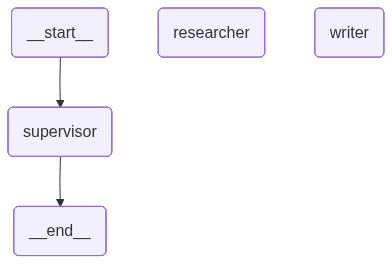

In [142]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)
app

In [143]:
config = {"configurable": {"thread_id": "team-blog-1"}}

In [144]:
# 실행: Supervisor → Researcher → Supervisor → Writer → Supervisor → FINISH
app.invoke(
    {"messages": [HumanMessage(content="AI 최신 트렌드에 대해 블로그 글 써줘")]},
    config=config
)


🤖 [Supervisor] 다음 작업자 결정 중...
👉 [지시] researcher (이유: AI 최신 트렌드는 빠르게 변하고 있어, 신뢰 가능한 최신 자료를 모아 현재의 핵심 트렌드(기술 진화: LLM/멀티모달/생성형 AI, 산업 적용 사례, 도구 생태계, 보안·윤리·데이터 프라이버시 이슈, 규제 동향, 직무 영향 등)를 정리하고, 근거 출처를 제시해 블로그 글의 기초 자료를 확보하기 위해 조사가 필요합니다.)

🔍 [Researcher] LLM이 자료를 조사/생성 중입니다...

🤖 [Supervisor] 다음 작업자 결정 중...
👉 [지시] writer (이유: 연구 결과를 바탕으로 AI 최신 트렌드 블로그 글 초안 작성.)

✍️ [Writer] LLM이 블로그 포스팅을 작성 중입니다...

🤖 [Supervisor] 다음 작업자 결정 중...
👉 [지시] researcher (이유: 요청하신 주제의 최신 트렌드와 관련 용어, 시장 수치를 정확히 파악하기 위해 연구자를 통해 조사 진행을 시작합니다.)

🔍 [Researcher] LLM이 자료를 조사/생성 중입니다...

🤖 [Supervisor] 다음 작업자 결정 중...
👉 [지시] writer (이유: 연구 결과를 바탕으로 블로그 글 작성을 시작합니다.)

✍️ [Writer] LLM이 블로그 포스팅을 작성 중입니다...

🤖 [Supervisor] 다음 작업자 결정 중...
👉 [지시] writer (이유: 조사 결과를 바탕으로 글 작성을 진행합니다. 이번 글은 핵심 트렌드(Foundation Model의 상용화 확산, 멀티모달/창의 AI의 일반화, 에지 인퍼런스 확장과 MLOps 고도화, 산업별 도입 가속), 주요 용어, 시장 수치를 반영한 블로그 포스트로 작성합니다.)

✍️ [Writer] LLM이 블로그 포스팅을 작성 중입니다...

🤖 [Supervisor] 다음 작업자 결정 중...
👉 [지시] FINISH (이유: 작성된 글이 최종 완성되어 FINISH를 선언합니다.)


{'messages': [HumanMessage(content='AI 최신 트렌드에 대해 블로그 글 써줘', additional_kwargs={}, response_metadata={}, id='837978e1-e314-46b5-bb47-4b5726b0d2cc'),
  HumanMessage(content='핵심 트렌드: LLM/foundation 모델의 상용화 확산, 멀티모달 및 창의적 AI의 일반화, 에지 인퍼런스 확대와 자동화된 ML(MLOps)으로 운영 효율화, 산업별 도입 가속(헬스케어/금융/제조).  \n기술 용어: Foundation Model, RLHF(강화학습으로 인간 피드백), 프롬프트 엔지니어링, 멀티모달 모델, 온디바이스 추론, 데이터 거버넌스와 AI 안전성 프레임워크, 파이프라인 오케스트레이션.  \n통계/시장: 2023–2024년 글로벌 AI 소프트웨어 지출은 연평균 20~30% 성장 전망, 데이터센터 GPU/AI 칩 수요 증가(H100/A100 등), 규제와 윤리 표준 확대로 컴플라이언스 비용과 리스크 관리의 중요성 증가.', additional_kwargs={}, response_metadata={}, name='Researcher', id='e53387d1-8c37-45fd-a636-d09a7409c495'),
  HumanMessage(content='제목: AI 최신 트렌드 2024-2025: 상용화 확대와 멀티모달·엣지 인퍼런스가 여는 비즈니스 혁신 🚀\n\n들어가며\n최근 AI 생태계는 더 빠르게 확장되고 있습니다. Foundation Model 기반의 상용화가 보편화되고, 멀티모달 및 창의 AI가 일반화되며, 엣지에서의 추론과 자동화된 ML(MLOps)이 운영 효율성을 한층 끌어올리고 있습니다. 산업 전반에서 도입이 가속화되며, 규제와 윤리 표준의 정교화도 비즈니스 리스크 관리의 핵심으로 자리 잡고 있습니다. 아래에서 핵심 트렌드를 정리합니다. 💡\n\n핵심 트렌드 정리\n- Foundation Model의 상용화 확산:

---
### 💬 생각해보기

새로운 작업자 '검수자(Reviewer)'를 추가한다면 어떻게 구현하면 될까요?

**힌트:**
1. `ReviewerState`나 `TeamState`에 필요한 필드를 추가합니다.
2. `reviewer_node` 함수를 작성합니다.
3. `RouteResponse`의 `next_step`에 `"reviewer"`를 추가합니다.
4. 감독관의 시스템 프롬프트에 검수자 역할을 명시합니다.


---
# 8. Multi-Agent (Handoff - 네트워크형)

## 개념 설명

**Handoff(핸드오프)** 패턴은 중앙 감독관 없이  
에이전트들이 **직접 서로에게 업무를 넘기는** 분산형 구조입니다.

```
[Receptionist] ──(기술 문제)──▶ [Tech Support] ──(환불 요청)──▶ [Billing]
               ◀──(해결 완료)──                  ◀──(해결 완료)──
```

### Supervisor vs Handoff

| 구분 | Supervisor | Handoff (Network) |
|------|-----------|-------------------|
| 조율 방식 | 중앙 집중 | 분산 (P2P) |
| 흐름 제어 | 감독관이 결정 | 각 에이전트가 직접 결정 |
| 적합한 경우 | 복잡한 조율 필요 시 | 독립적인 전문 부서 |

### ToolRuntime
핸드오프 도구(transfer_to_*)가 실행될 때 `ToolRuntime`을 통해  
현재 tool_call_id 등 런타임 정보에 접근할 수 있습니다.

### 참고 문서
- [LangGraph Handoff 공식 문서](https://docs.langchain.com/oss/python/langchain/multi-agent/handoffs)
- [OpenAI Handoff](https://openai.github.io/openai-agents-python/handoffs/)


## Model & Tool 정의

In [145]:
from langchain.chat_models import init_chat_model
model = init_chat_model("gpt-5-nano")

In [146]:
from langgraph.types import Command
from langchain.messages import ToolMessage
from langchain.tools import tool, ToolRuntime

# ─── 핸드오프 도구: 기술 지원팀으로 이동 ───
@tool
def transfer_to_tech_support(runtime: ToolRuntime):
    """기술적인 문제(컴퓨터, 코드, 에러 등)를 해결해야 할 때 이 도구를 사용하여 기술팀으로 연결하세요."""

    # ToolRuntime: 도구 실행 시 자동으로 주입되는 런타임 정보
    # tool_call_id: 이 도구 호출을 고유하게 식별하는 ID
    tool_id = runtime.tool_call_id
    print(f" [System] 기술 지원팀으로 이동합니다... (Tool Call ID: {tool_id})")

    return Command(
        update={
            "messages": [
                ToolMessage(
                    content="기술 지원팀으로 성공적으로 연결되었습니다.",
                    tool_call_id=tool_id
                )
            ]
        },
        goto="tech_support"  # tech_node로 즉시 이동
    )

In [147]:
# ─── 핸드오프 도구: 환불팀으로 이동 ───
@tool
def transfer_to_billing(runtime: ToolRuntime):
    """환불, 결제, 금액 관련 문제를 해결해야 할 때 이 도구를 사용하여 환불팀으로 연결하세요."""

    tool_id = runtime.tool_call_id
    print(f" [System] 환불팀으로 이동합니다... (Tool Call ID: {tool_id})")

    return Command(
        update={
            "messages": [
                ToolMessage(
                    content="환불/결제팀으로 성공적으로 연결되었습니다.",
                    tool_call_id=tool_id
                )
            ]
        },
        goto="billing"  # billing_node로 이동
    )

In [148]:
# ─── 핸드오프 도구: 안내 데스크로 복귀 ───
@tool
def transfer_to_reception(runtime: ToolRuntime):
    """일반적인 문의거나, 인사가 끝났으면 안내 데스크로 다시 연결하세요."""

    tool_id = runtime.tool_call_id
    print(f" [System] 안내 데스크로 복귀합니다... (Tool Call ID: {tool_id})")

    return Command(
        update={
            "messages": [
                ToolMessage(
                    content="안내 데스크로 복귀했습니다.",
                    tool_call_id=tool_id
                )
            ]
        },
        goto="receptionist"  # receptionist_node로 복귀
    )

## State 정의

In [149]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # 모든 에이전트가 공유하는 대화 기록
    messages: Annotated[list[AnyMessage], add_messages]

## Node 정의

### Agent Nodes

In [150]:
# [상담원 1] 안내 데스크 - 시작점, 기술팀/환불팀으로 전달 가능
def receptionist_node(state: AgentState):
    print("\n💁 [Reception] 안녕하세요.")

    system_prompt = """
    당신은 고객센터의 친절한 안내 데스크입니다.
    1. 고객의 말을 듣고 인사하세요.
    2. '기술 문제'라면 transfer_to_tech_support 도구를 쓰세요.
    3. '돈/환불 문제'라면 transfer_to_billing 도구를 쓰세요.
    4. 그 외 잡담은 직접 답변하세요.
    """

    # 안내 데스크는 기술팀과 환불팀으로 보낼 수 있습니다.
    tools = [transfer_to_tech_support, transfer_to_billing]
    model_with_tools = model.bind_tools(tools)

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

In [151]:
# [상담원 2] 기술 지원팀 - 기술 문제 해결 후 안내 데스크로 복귀
def tech_node(state: AgentState):
    print("\n🛠️ [Tech Support] 기술적인 문제를 해결해드립니다.")

    system_prompt = """
    당신은 베테랑 기술 지원 엔지니어입니다.
    컴퓨터 고장, 파이썬 코드 에러 등을 해결해줍니다.
    만약 고객이 '환불'을 요구하면 즉시 transfer_to_billing 도구를 써서 넘기세요.
    해결이 끝나면 transfer_to_reception으로 넘기세요.
    """

    # 기술팀은 환불팀이나 안내 데스크로 보낼 수 있습니다.
    tools = [transfer_to_billing, transfer_to_reception]
    model_with_tools = model.bind_tools(tools)

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

In [152]:
# [상담원 3] 환불팀 - 결제/환불 처리 후 안내 데스크로 복귀
def billing_node(state: AgentState):
    print("\n💰 [Billing] 결제 및 환불 담당입니다.")

    system_prompt = """
    당신은 환불 담당자입니다.
    고객의 환불 요청을 처리해줍니다.
    기술적인 질문을 하면 transfer_to_tech_support로 넘기세요.
    해결이 끝나면 transfer_to_reception으로 넘기세요.
    """

    # 환불팀은 기술팀이나 안내 데스크로 보낼 수 있습니다.
    tools = [transfer_to_tech_support, transfer_to_reception]
    model_with_tools = model.bind_tools(tools)

    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}

In [153]:
from langgraph.prebuilt import ToolNode

# ToolNode: 에이전트가 도구를 호출하면 이 노드가 실제 함수를 실행합니다.
# 흐름: 에이전트 → ToolNode에서 함수 실행 → Command 반환 → 다른 노드로 점프
all_tools = [transfer_to_tech_support, transfer_to_billing, transfer_to_reception]
tool_node = ToolNode(all_tools)
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'transfer_to_tech_support': StructuredTool(name='transfer_to_tech_support', description='기술적인 문제(컴퓨터, 코드, 에러 등)를 해결해야 할 때 이 도구를 사용하여 기술팀으로 연결하세요.', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_tech_support'>, func=<function transfer_to_tech_support at 0x000001691A3418A0>), 'transfer_to_billing': StructuredTool(name='transfer_to_billing', description='환불, 결제, 금액 관련 문제를 해결해야 할 때 이 도구를 사용하여 환불팀으로 연결하세요.', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_billing'>, func=<function transfer_to_billing at 0x000001691A44B880>), 'transfer_to_reception': StructuredTool(name='transfer_to_reception', description='일반적인 문의거나, 인사가 끝났으면 안내 데스크로 다시 연결하세요.', args_schema=<class 'langchain_core.utils.pydantic.transfer_to_reception'>, func=<function transfer_to_reception at 0x000001691A502160>)}, _injected_

## 그래프 생성

In [154]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("receptionist", receptionist_node)
workflow.add_node("tech_support", tech_node)
workflow.add_node("billing", billing_node)

In [155]:
# 도구 실행 노드 등록
workflow.add_node("tools", tool_node)

In [156]:
# 시작은 안내 데스크
workflow.add_edge(START, "receptionist")

In [157]:
from langgraph.prebuilt import tools_condition

# tools_condition: 마지막 메시지에 tool_call이 있으면 'tools'로, 없으면 END로 분기
# 모든 에이전트 노드에 이 조건부 엣지를 적용합니다.
workflow.add_conditional_edges("receptionist", tools_condition, ["tools", END])
workflow.add_conditional_edges("tech_support", tools_condition, ["tools", END])
workflow.add_conditional_edges("billing", tools_condition, ["tools", END])

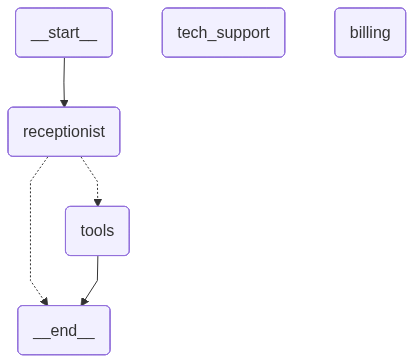

In [158]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)
app

In [159]:
config = {"configurable": {"thread_id": "handoff-demo-1"}}

In [160]:
# 시나리오 1: 기술 문제 접수
# 안내 데스크 → (transfer_to_tech_support 도구) → 기술 지원팀
result = app.invoke(
    {"messages": [HumanMessage(content="제 컴퓨터 화면이 안 나와요. 고장난 것 같아요.")]},
    config=config
)
result


💁 [Reception] 안녕하세요.
 [System] 기술 지원팀으로 이동합니다... (Tool Call ID: call_JbqH3rGVDbdrtHQikKryFx4s)

🛠️ [Tech Support] 기술적인 문제를 해결해드립니다.


{'messages': [HumanMessage(content='제 컴퓨터 화면이 안 나와요. 고장난 것 같아요.', additional_kwargs={}, response_metadata={}, id='d7e838f0-0f67-4279-bd0a-38f872f929af'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 726, 'prompt_tokens': 289, 'total_tokens': 1015, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5gaDSojQT0QQFdPE3agIOh5OBnF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce968-6886-7082-b8e4-507bf8db9940-0', tool_calls=[{'name': 'transfer_to_tech_support', 'args': {}, 'id': 'call_JbqH3rGVDbdrtHQikKryFx4s', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 289, 'output_tokens':

In [161]:
# 시나리오 2: 기술팀에서 환불 요청으로 전환
# 기술 지원팀 → (transfer_to_billing 도구) → 환불팀
result = app.invoke(
    {"messages": [HumanMessage(content="아직 안 되는데, 그냥 환불하고 싶어요.")]},
    config=config
)
result


💁 [Reception] 안녕하세요.
 [System] 환불팀으로 이동합니다... (Tool Call ID: call_eDPfyhSr7W3SewpxQwWBNdN3)

💰 [Billing] 결제 및 환불 담당입니다.
 [System] 안내 데스크로 복귀합니다... (Tool Call ID: call_GsfenSLGbwyDF8XCbjKE7kon)

💁 [Reception] 안녕하세요.


{'messages': [HumanMessage(content='제 컴퓨터 화면이 안 나와요. 고장난 것 같아요.', additional_kwargs={}, response_metadata={}, id='d7e838f0-0f67-4279-bd0a-38f872f929af'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 726, 'prompt_tokens': 289, 'total_tokens': 1015, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DJ5gaDSojQT0QQFdPE3agIOh5OBnF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce968-6886-7082-b8e4-507bf8db9940-0', tool_calls=[{'name': 'transfer_to_tech_support', 'args': {}, 'id': 'call_JbqH3rGVDbdrtHQikKryFx4s', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 289, 'output_tokens':